# StarDist 2D — Grid Search Cepat, Stabil, dan GPU-Aware

Notebook ini disusun ulang untuk mengatasi grid search yang macet/lambat pada StarDist.

Perbaikan utama:
1. **Forward pass CNN di-cache 1x** pada gambar tuning, lalu kombinasi `prob_thresh` dan `nms_thresh` hanya mengulang post-processing.
2. **ROI/tissue mask diterapkan sebelum NMS**, sehingga kandidat di luar jaringan tidak ikut membebani post-processing.
3. **Grid search tidak dimulai dari kombinasi patologis** seperti `prob_thresh=0.0` secara lexicographic.
4. **Ada guard kandidat** untuk melewati kombinasi yang hampir pasti meledak pada tahap NMS.
5. **Evaluasi instance dipercepat** dengan overlap matrix berbasis `np.bincount`, bukan loop GT×Pred per objek.
6. **Seleksi parameter 2 tahap**: 
   - tahap ringan untuk semua kombinasi,
   - tahap penuh hanya untuk kandidat terbaik.


## Catatan penting

- Secara desain, **GPU terutama mempercepat forward pass jaringan**. Pada StarDist, setelah `predict`, masih ada tahap **non-maximum suppression (NMS)** dan rendering label yang dapat menjadi bottleneck bila kandidat terlalu banyak.
- Nilai `prob_thresh` yang sangat rendah sering membuat jumlah kandidat meledak, sehingga kombinasi seperti `prob_thresh=0.0` dapat terasa seperti hang.
- Notebook ini tetap mendukung **grid 0.0–1.0** bila Anda ingin, tetapi mode default dibuat lebih aman dan jauh lebih cepat.

Ganti nilai konfigurasi pada sel konfigurasi jika ingin:
- mempertahankan **full brute-force 0.0–1.0**,
- menonaktifkan tissue mask,
- mengubah tuning image tertentu,
- atau mengubah strategi seleksi parameter akhir.


In [ ]:
# HANYA KETIKA DEPENDENSI TIDAK TERSEDIA DAN FILE WHEEL TELAH DISIAPKAN
# # Jalankan sel ini sebelum sel lain.
# # Tujuan:
# # 1) memastikan package inti tersedia,
# # 2) memeriksa TensorFlow GPU runtime,
# # 3) memberikan diagnosis cepat bila notebook diam-diam jatuh ke CPU.

# import importlib.util
# import json
# import platform
# import shutil
# import subprocess
# import sys
# from pathlib import Path

# try:
#     import importlib.metadata as importlib_metadata
# except Exception:  # pragma: no cover
#     import importlib_metadata

# PREFER_GPU_RUNTIME = True
# ALLOW_PYPI_FALLBACK = True
# FORCE_REPAIR_TF_GPU = False

# required_modules = [
#     "csbdeep",
#     "stardist",
#     "skimage",
#     "tifffile",
#     "imageio",
#     "matplotlib",
#     "pandas",
#     "tqdm",
#     "openpyxl",
#     "scipy",
#     "sklearn",
# ]

# BASE_PACKAGES = [
#     "csbdeep==0.7.4",
#     "stardist==0.8.3",
#     "scikit-image==0.21.*",
#     "tifffile",
#     "imageio",
#     "matplotlib",
#     "pandas",
#     "tqdm",
#     "openpyxl",
#     "scipy",
#     "scikit-learn",
# ]

# WHEELS_DIR = Path("/data/work/stardist_offline_wheels")

# def _run_capture(cmd):
#     return subprocess.run(cmd, capture_output=True, text=True)

# def _json_from_python(code: str):
#     result = _run_capture([sys.executable, "-c", code])
#     if result.returncode != 0:
#         return {
#             "ok": False,
#             "stdout": result.stdout.strip(),
#             "stderr": result.stderr.strip(),
#         }

#     stdout = (result.stdout or "").strip()
#     if not stdout:
#         return {"ok": True}

#     last_line = stdout.splitlines()[-1]
#     try:
#         payload = json.loads(last_line)
#         payload["ok"] = True
#         return payload
#     except Exception:
#         return {
#             "ok": True,
#             "raw_stdout": stdout,
#             "raw_stderr": result.stderr.strip(),
#         }

# def detect_nvidia_gpus():
#     if shutil.which("nvidia-smi") is None:
#         return []

#     cmd = [
#         "nvidia-smi",
#         "--query-gpu=index,name,memory.total,driver_version",
#         "--format=csv,noheader",
#     ]
#     result = _run_capture(cmd)
#     if result.returncode != 0:
#         return []
#     return [line.strip() for line in result.stdout.splitlines() if line.strip()]

# def inspect_tensorflow_runtime():
#     probe_code = r"""
# import json
# import importlib.util

# info = {
#     "installed": False,
#     "version": None,
#     "gpu_devices": [],
#     "import_error": None,
# }

# if importlib.util.find_spec("tensorflow") is not None:
#     info["installed"] = True
#     try:
#         import tensorflow as tf
#         info["version"] = tf.__version__
#         info["gpu_devices"] = [getattr(dev, "name", str(dev)) for dev in tf.config.list_physical_devices("GPU")]
#     except Exception as exc:
#         info["import_error"] = repr(exc)

# print(json.dumps(info))
# """
#     return _json_from_python(probe_code)

# def get_installed_dist_version(dist_name: str):
#     try:
#         return importlib_metadata.version(dist_name)
#     except importlib_metadata.PackageNotFoundError:
#         return None
#     except Exception:
#         return None

# def pip_install(packages, use_wheels: bool = True):
#     packages = list(packages)
#     if not packages:
#         return

#     if use_wheels and WHEELS_DIR.exists():
#         offline_cmd = [
#             sys.executable, "-m", "pip", "install",
#             "--no-index",
#             "--find-links", str(WHEELS_DIR),
#             *packages,
#         ]
#         print("Install offline :", " ".join(offline_cmd))
#         result = subprocess.run(offline_cmd, text=True)
#         if result.returncode == 0:
#             return
#         print("⚠ Install offline gagal. Akan fallback ke PyPI bila diizinkan.")

#     if not ALLOW_PYPI_FALLBACK:
#         raise RuntimeError(
#             "Package belum lengkap, tetapi fallback ke PyPI dimatikan. "
#             "Aktifkan internet atau sediakan wheel di WHEELS_DIR."
#         )

#     online_cmd = [sys.executable, "-m", "pip", "install", *packages]
#     print("Install PyPI    :", " ".join(online_cmd))
#     subprocess.check_call(online_cmd)

# nvidia_gpus = detect_nvidia_gpus()
# prefer_gpu_runtime = bool(PREFER_GPU_RUNTIME) and bool(nvidia_gpus) and platform.system().lower() == "linux"

# missing_base = [m for m in required_modules if importlib.util.find_spec(m) is None]
# tf_state_before = inspect_tensorflow_runtime()
# tf_installed_version = get_installed_dist_version("tensorflow")

# print("Python               :", sys.version.split()[0])
# print("Platform             :", platform.platform())
# print("NVIDIA GPUs          :", nvidia_gpus if nvidia_gpus else "(tidak terdeteksi via nvidia-smi)")
# print("Missing base modules :", missing_base if missing_base else "(none)")
# print("TensorFlow before    :", tf_state_before)
# print("TensorFlow dist ver  :", tf_installed_version)

# if missing_base:
#     pip_install(BASE_PACKAGES, use_wheels=True)

# need_tf_install = not tf_state_before.get("installed", False)
# need_tf_gpu_repair = prefer_gpu_runtime and (
#     FORCE_REPAIR_TF_GPU or (
#         tf_state_before.get("installed", False) and not tf_state_before.get("gpu_devices")
#     )
# )

# if need_tf_install or need_tf_gpu_repair:
#     if prefer_gpu_runtime and tf_installed_version:
#         tf_pkg = f"tensorflow[and-cuda]=={tf_installed_version}"
#     else:
#         tf_pkg = "tensorflow[and-cuda]" if prefer_gpu_runtime else "tensorflow"

#     print(f"Memastikan TensorFlow runtime: {tf_pkg}")
#     try:
#         pip_install([tf_pkg], use_wheels=False)
#     except Exception as exc:
#         if prefer_gpu_runtime and tf_installed_version:
#             print("⚠ Install TensorFlow versi yang sama gagal. Mencoba fallback ke tensorflow[and-cuda] terbaru...")
#             pip_install(["tensorflow[and-cuda]"], use_wheels=False)
#         else:
#             raise exc

# tf_state_after = inspect_tensorflow_runtime()
# print("TensorFlow after     :", tf_state_after)

# if prefer_gpu_runtime and not tf_state_after.get("gpu_devices"):
#     print(
#         "⚠ GPU NVIDIA terdeteksi tetapi TensorFlow belum melihat GPU.\n"
#         "Pastikan image/venv memang GPU-enabled, driver NVIDIA aktif, dan dependency CUDA benar."
#     )
# else:
#     print("Dependency bootstrap selesai.")


In [2]:

import itertools
import json
import math
import os
import sys
import time
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tifffile
from IPython.display import display
from scipy.optimize import linear_sum_assignment
from skimage import color, filters, io, measure, morphology, transform
from skimage.segmentation import find_boundaries, relabel_sequential
from sklearn.metrics import matthews_corrcoef
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)


In [3]:

# =========================
# KONFIGURASI EKSPERIMEN
# =========================
IMAGE_DIR = Path("/data/work/InferencePretrained/Images")
MASK_DIR = Path("/data/work/InferencePretrained/MaskInstance")
OUTPUT_ROOT = Path("/data/work/InferencePretrained/StarDist_Fast_GridSearch_V5")

MODEL_NAME = "stardist_2D_versatile_he"
# MODEL_DIR = Path("/data/work/FROM_SCRATCH/models/stardist_model_A")
MODEL_DIR = Path("/data/work/python_2D_versatile_he")
PRETRAINED_MODEL_NAME = "2D_versatile_he"
ALLOW_PRETRAINED_DOWNLOAD = False

# Jika None, notebook akan memilih pasangan pertama setelah sorting filename
TUNING_IMAGE_STEM: Optional[str] = None

# =========================
# GPU / TensorFlow runtime
# =========================
USE_GPU = False
REQUIRE_GPU_WHEN_ENABLED = True
GPU_DEVICE_INDEX = 0
TF_MEMORY_GROWTH = True
TF_ENABLE_XLA = False
TF_ENABLE_MIXED_PRECISION = False

# Preprocessing StarDist untuk H&E
NORMALIZE_PERCENTILE = True
USE_TISSUE_MASK = True
MASK_OUTSIDE_ROI = True
APPLY_ROI_BEFORE_NMS = True
STARDIST_AXES = "YXC"

# Parameter tambahan inferensi
N_TILES: Optional[Tuple[int, int]] = None   # contoh: (2, 2) bila image besar
PREDICTION_NMS_THRESH_FALLBACK = 0.3
PREDICTION_PROB_THRESH_FALLBACK = 0.5

# =========================
# Strategi grid search
# =========================
# "coarse_to_fine"  : default yang lebih cepat/stabil
# "full_safe_0_1"   : tetap menjalankan ruang 0.0–1.0, tetapi
#                     urutan kombinasi diubah agar tidak mulai dari area patologis
GRID_SEARCH_MODE = "full_safe_0_1"

# Nilai untuk coarse search (lebih aman daripada memulai dari prob=0.0)
GRID_COARSE_VALUES = [round(float(x), 2) for x in np.arange(0.1, 0.91, 0.1)]

# Nilai untuk full search 0.0–1.0 sesuai konsep awal
GRID_FULL_VALUES = [round(float(x), 2) for x in np.arange(0.0, 1.01, 0.1)]

# Fine search di sekitar seed terbaik
GRID_FINE_RADIUS = 0.15
GRID_FINE_STEP = 0.05
TOPK_FINE_SEEDS = 3

# Tahap seleksi
TOPK_FULL_EVAL = 10  # hanya kandidat terbaik dari stage ringan yang dihitung metrik lengkap

# Cache output jaringan 1x untuk gambar tuning
GRID_SEARCH_USE_CACHED_NETWORK_OUTPUT = True

# Guard agar kombinasi patologis tidak menghabiskan waktu berjam-jam di NMS
# Nilai ini bisa dinaikkan bila jaringan Anda sangat padat.
MAX_GRID_CANDIDATES = 25000


# Penyimpanan progress
GRID_SEARCH_FLUSH_EVERY = 5
GRID_SEARCH_RESUME = True

# Threshold object-level F1
F1_THRESHOLDS = [0.3, 0.5, 0.6, 0.7, 0.8, 0.9]

# Output
GRID_DIR = OUTPUT_ROOT / "01_grid_search"
PER_IMAGE_DIR = OUTPUT_ROOT / "02_hasil_inferensi_per_gambar"
SUMMARY_DIR = OUTPUT_ROOT / "03_ringkasan_rata_rata_metrik"

for folder in [OUTPUT_ROOT, GRID_DIR, PER_IMAGE_DIR, SUMMARY_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

RUN_CONFIG_PATH = OUTPUT_ROOT / "run_config.json"
MODEL_INFO_PATH = OUTPUT_ROOT / "model_resolution_info.json"

print("Image dir                      :", IMAGE_DIR)
print("Mask dir                       :", MASK_DIR)
print("Model dir                      :", MODEL_DIR)
print("Output root                    :", OUTPUT_ROOT)
print("Grid search mode               :", GRID_SEARCH_MODE)
print("Grid coarse values             :", GRID_COARSE_VALUES)
print("Grid full values               :", GRID_FULL_VALUES)
print("Allow download                 :", ALLOW_PRETRAINED_DOWNLOAD)
print("Use GPU                        :", USE_GPU)
print("Require GPU                    :", REQUIRE_GPU_WHEN_ENABLED)
print("GPU device index               :", GPU_DEVICE_INDEX)
print("TF memory growth               :", TF_MEMORY_GROWTH)
print("TF enable XLA                  :", TF_ENABLE_XLA)
print("TF mixed precision             :", TF_ENABLE_MIXED_PRECISION)
print("Grid search cached forward     :", GRID_SEARCH_USE_CACHED_NETWORK_OUTPUT)
print("Normalize percentile           :", NORMALIZE_PERCENTILE)
print("Use tissue mask                :", USE_TISSUE_MASK)
print("ROI before NMS                 :", APPLY_ROI_BEFORE_NMS)
print("Max grid candidates            :", MAX_GRID_CANDIDATES)


Image dir                      : /data/work/InferencePretrained/Images
Mask dir                       : /data/work/InferencePretrained/MaskInstance
Model dir                      : /data/work/python_2D_versatile_he
Output root                    : /data/work/InferencePretrained/StarDist_Fast_GridSearch_V5
Grid search mode               : full_safe_0_1
Grid coarse values             : [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
Grid full values               : [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
Allow download                 : False
Use GPU                        : False
Require GPU                    : True
GPU device index               : 0
TF memory growth               : True
TF enable XLA                  : False
TF mixed precision             : False
Grid search cached forward     : True
Normalize percentile           : True
Use tissue mask                : True
ROI before NMS                 : True
Max grid candidates            : 25000


In [4]:

# =========================
# UTILITAS DATASET
# =========================
IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}
MASK_EXTS = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}

@dataclass
class DataPair:
    stem: str
    image_path: Path
    mask_path: Path

def build_stem_index(folder: Path, valid_exts: Sequence[str]) -> Dict[str, Path]:
    folder = Path(folder)
    if not folder.exists():
        raise FileNotFoundError(f"Folder tidak ditemukan: {folder}")
    idx: Dict[str, Path] = {}
    for fp in sorted(folder.iterdir()):
        if not fp.is_file():
            continue
        if fp.suffix.lower() not in valid_exts:
            continue
        idx[fp.stem] = fp
    return idx

def pair_image_and_mask_files(image_dir: Path, mask_dir: Path) -> List[DataPair]:
    image_idx = build_stem_index(image_dir, IMAGE_EXTS)
    mask_idx = build_stem_index(mask_dir, MASK_EXTS)

    common = sorted(set(image_idx) & set(mask_idx))
    missing_images = sorted(set(mask_idx) - set(image_idx))
    missing_masks = sorted(set(image_idx) - set(mask_idx))

    if missing_images:
        print(f"⚠ Mask ada tetapi image tidak ada ({len(missing_images)}): {missing_images[:5]}")
    if missing_masks:
        print(f"⚠ Image ada tetapi mask tidak ada ({len(missing_masks)}): {missing_masks[:5]}")

    if not common:
        raise RuntimeError("Tidak ada pasangan image-mask yang cocok berdasarkan stem filename.")

    return [DataPair(stem=s, image_path=image_idx[s], mask_path=mask_idx[s]) for s in common]

def load_image_any(path: Path) -> np.ndarray:
    arr = io.imread(str(path))
    if arr.ndim == 3 and arr.shape[-1] == 4:
        arr = arr[..., :3]
    return arr

def relabel_compact(mask: np.ndarray) -> np.ndarray:
    return relabel_sequential(np.asarray(mask).astype(np.int32))[0].astype(np.int32)

def load_instance_mask(path: Path) -> np.ndarray:
    arr = io.imread(str(path))
    if arr.ndim == 3:
        arr = arr[..., 0]
    arr = np.asarray(arr)
    if not np.issubdtype(arr.dtype, np.integer):
        arr = np.rint(arr).astype(np.int32)
    return relabel_compact(arr)

def to_binary(mask: np.ndarray) -> np.ndarray:
    return (np.asarray(mask) > 0).astype(np.uint8)

def normalize_for_display(img: np.ndarray) -> np.ndarray:
    arr = np.asarray(img)
    if arr.ndim == 2:
        arr = np.stack([arr] * 3, axis=-1)

    arr = arr.astype(np.float32)
    arr = arr - arr.min()
    mx = float(arr.max())
    if mx > 0:
        arr = arr / mx
    return arr

def save_binary_png(path: Path, mask_bin: np.ndarray) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    io.imsave(str(path), (mask_bin > 0).astype(np.uint8) * 255, check_contrast=False)

def save_json(path: Path, data: Dict[str, Any]) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    def _default(x):
        if isinstance(x, (np.integer,)):
            return int(x)
        if isinstance(x, (np.floating,)):
            return float(x)
        if isinstance(x, np.ndarray):
            return x.tolist()
        return str(x)

    path.write_text(json.dumps(data, indent=2, ensure_ascii=False, default=_default), encoding="utf-8")

def estimate_mask_diameter_from_gt(gt_inst: np.ndarray, fallback: float = 30.0) -> float:
    props = measure.regionprops(gt_inst)
    if not props:
        return float(fallback)
    eq_diams = [float(p.equivalent_diameter) for p in props if p.area > 0]
    if not eq_diams:
        return float(fallback)
    return float(np.median(eq_diams))

pairs = pair_image_and_mask_files(IMAGE_DIR, MASK_DIR)
pairs_df = pd.DataFrame(
    [{"stem": p.stem, "image_path": str(p.image_path), "mask_path": str(p.mask_path)} for p in pairs]
).sort_values("stem").reset_index(drop=True)

display(pairs_df.head())
print("Jumlah pasangan cocok:", len(pairs_df))

pairs_df.to_csv(OUTPUT_ROOT / "paired_input_files.csv", index=False)
print("File pairing tersimpan di:", OUTPUT_ROOT / "paired_input_files.csv")


,stem,image_path,mask_path
0,C04042E3_HE_regist_x04608_y09216,/data/work/InferencePretrained/Images/C04042E3...,/data/work/InferencePretrained/MaskInstance/C0...
1,C04042E3_HE_regist_x05632_y09728,/data/work/InferencePretrained/Images/C04042E3...,/data/work/InferencePretrained/MaskInstance/C0...
2,C04042E3_HE_regist_x07168_y11776,/data/work/InferencePretrained/Images/C04042E3...,/data/work/InferencePretrained/MaskInstance/C0...
3,C04042E3_HE_regist_x08192_y05120,/data/work/InferencePretrained/Images/C04042E3...,/data/work/InferencePretrained/MaskInstance/C0...
4,C04042E3_HE_regist_x08192_y10240,/data/work/InferencePretrained/Images/C04042E3...,/data/work/InferencePretrained/MaskInstance/C0...


Jumlah pasangan cocok: 10
File pairing tersimpan di: /data/work/InferencePretrained/StarDist_Fast_GridSearch_V5/paired_input_files.csv


In [5]:

# =========================
# EVALUASI CEPAT BERBASIS OVERLAP MATRIX
# =========================
@dataclass
class OverlapCache:
    gt_inst: np.ndarray
    pred_inst: np.ndarray
    gt_ids: np.ndarray
    pred_ids: np.ndarray
    gt_areas: np.ndarray
    pred_areas: np.ndarray
    intersections: np.ndarray
    unions: np.ndarray
    iou: np.ndarray

def safe_mcc(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    try:
        return float(matthews_corrcoef(y_true.astype(int), y_pred.astype(int)))
    except Exception:
        return 0.0

def pixel_metrics(gt_bin: np.ndarray, pred_bin: np.ndarray) -> Dict[str, float]:
    gt = gt_bin.flatten().astype(bool)
    pred = pred_bin.flatten().astype(bool)

    TP = np.logical_and(pred, gt).sum()
    FP = np.logical_and(pred, ~gt).sum()
    FN = np.logical_and(~pred, gt).sum()
    TN = np.logical_and(~pred, ~gt).sum()

    precision = TP / (TP + FP + 1e-8)
    recall = TP / (TP + FN + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    iou = TP / (TP + FP + FN + 1e-8)
    dice = 2 * TP / (2 * TP + FP + FN + 1e-8)
    specificity = TN / (TN + FP + 1e-8)
    mcc = safe_mcc(gt.astype(int), pred.astype(int))

    return {
        "Precision": round(float(precision), 6),
        "Recall": round(float(recall), 6),
        "F1": round(float(f1), 6),
        "IoU": round(float(iou), 6),
        "Dice": round(float(dice), 6),
        "Specificity": round(float(specificity), 6),
        "MCC": round(float(mcc), 6),
        "TP_pixels": int(TP),
        "FP_pixels": int(FP),
        "FN_pixels": int(FN),
        "TN_pixels": int(TN),
    }

def build_overlap_cache(gt_inst: np.ndarray, pred_inst: np.ndarray) -> OverlapCache:
    gt = relabel_compact(gt_inst)
    pred = relabel_compact(pred_inst)

    n_gt = int(gt.max())
    n_pred = int(pred.max())

    gt_ids = np.arange(1, n_gt + 1, dtype=np.int32)
    pred_ids = np.arange(1, n_pred + 1, dtype=np.int32)

    gt_areas_full = np.bincount(gt.ravel(), minlength=n_gt + 1).astype(np.int64)
    pred_areas_full = np.bincount(pred.ravel(), minlength=n_pred + 1).astype(np.int64)

    gt_areas = gt_areas_full[1:]
    pred_areas = pred_areas_full[1:]

    if n_gt == 0 or n_pred == 0:
        intersections = np.zeros((n_gt, n_pred), dtype=np.int64)
        unions = np.zeros((n_gt, n_pred), dtype=np.int64)
        iou = np.zeros((n_gt, n_pred), dtype=np.float32)
        return OverlapCache(
            gt_inst=gt,
            pred_inst=pred,
            gt_ids=gt_ids,
            pred_ids=pred_ids,
            gt_areas=gt_areas,
            pred_areas=pred_areas,
            intersections=intersections,
            unions=unions,
            iou=iou,
        )

    pair_index = gt.ravel().astype(np.int64) * (n_pred + 1) + pred.ravel().astype(np.int64)
    overlap_full = np.bincount(pair_index, minlength=(n_gt + 1) * (n_pred + 1)).reshape(n_gt + 1, n_pred + 1)
    intersections = overlap_full[1:, 1:].astype(np.int64, copy=False)

    unions = gt_areas[:, None] + pred_areas[None, :] - intersections
    iou = np.divide(
        intersections,
        unions,
        out=np.zeros_like(unions, dtype=np.float32),
        where=unions > 0,
    )

    return OverlapCache(
        gt_inst=gt,
        pred_inst=pred,
        gt_ids=gt_ids,
        pred_ids=pred_ids,
        gt_areas=gt_areas,
        pred_areas=pred_areas,
        intersections=intersections,
        unions=unions,
        iou=iou.astype(np.float32, copy=False),
    )

def match_instances_from_cache(cache: OverlapCache, iou_threshold: float = 0.5):
    if cache.iou.size == 0:
        return [], [int(x) for x in cache.gt_ids], [int(x) for x in cache.pred_ids]

    row_ind, col_ind = linear_sum_assignment(-cache.iou)
    matched_mask = cache.iou[row_ind, col_ind] >= float(iou_threshold)

    matched_rows = set(int(r) for r in row_ind[matched_mask])
    matched_cols = set(int(c) for c in col_ind[matched_mask])

    matched_pairs = [
        (int(cache.gt_ids[r]), int(cache.pred_ids[c]), float(cache.iou[r, c]))
        for r, c in zip(row_ind[matched_mask], col_ind[matched_mask])
    ]

    unmatched_gt = [int(cache.gt_ids[i]) for i in range(len(cache.gt_ids)) if i not in matched_rows]
    unmatched_pred = [int(cache.pred_ids[i]) for i in range(len(cache.pred_ids)) if i not in matched_cols]
    return matched_pairs, unmatched_gt, unmatched_pred

def compute_aji_from_cache(cache: OverlapCache) -> float:
    # AJI memakai pairing satu-ke-satu agar lebih stabil dan tidak double-count
    # satu prediksi yang sama ke banyak GT.
    if len(cache.gt_ids) == 0:
        return 0.0

    total_intersection = 0.0
    total_union = 0.0
    matched_rows: set[int] = set()
    matched_cols: set[int] = set()

    if cache.iou.size > 0:
        row_ind, col_ind = linear_sum_assignment(-cache.iou)
        for r, c in zip(row_ind, col_ind):
            inter = float(cache.intersections[r, c])
            if inter <= 0:
                continue
            total_intersection += inter
            total_union += float(cache.unions[r, c])
            matched_rows.add(int(r))
            matched_cols.add(int(c))

    for r in range(len(cache.gt_ids)):
        if r not in matched_rows:
            total_union += float(cache.gt_areas[r])

    for c in range(len(cache.pred_ids)):
        if c not in matched_cols:
            total_union += float(cache.pred_areas[c])

    return round(float(total_intersection) / (float(total_union) + 1e-8), 6)

def compute_pq_from_cache(cache: OverlapCache, iou_threshold: float = 0.5) -> Dict[str, float]:
    matched_pairs, unmatched_gt, unmatched_pred = match_instances_from_cache(cache, iou_threshold=iou_threshold)

    TP = len(matched_pairs)
    FP = len(unmatched_pred)
    FN = len(unmatched_gt)

    dq = TP / (TP + 0.5 * FP + 0.5 * FN + 1e-8)
    sq = float(np.mean([p[2] for p in matched_pairs])) if TP > 0 else 0.0
    pq = dq * sq

    return {
        "PQ": round(float(pq), 6),
        "DQ": round(float(dq), 6),
        "SQ": round(float(sq), 6),
        "TP_objects": int(TP),
        "FP_objects": int(FP),
        "FN_objects": int(FN),
    }

def object_f1_at_thresholds_from_cache(
    cache: OverlapCache,
    thresholds: Sequence[float] = (0.3, 0.5, 0.6, 0.7, 0.8, 0.9),
) -> Dict[str, float]:
    results: Dict[str, float] = {}
    for t in thresholds:
        matched, unmatched_gt, unmatched_pred = match_instances_from_cache(cache, iou_threshold=float(t))
        TP = len(matched)
        FP = len(unmatched_pred)
        FN = len(unmatched_gt)
        precision = TP / (TP + FP + 1e-8)
        recall = TP / (TP + FN + 1e-8)
        f1 = 2 * precision * recall / (precision + recall + 1e-8)
        results[f"F1@{t}"] = round(float(f1), 6)
    return results

def count_metrics_from_cache(cache: OverlapCache, iou_threshold: float = 0.5) -> Dict[str, float]:
    n_gt = int(len(cache.gt_ids))
    n_pred = int(len(cache.pred_ids))
    matched, unmatched_gt, unmatched_pred = match_instances_from_cache(cache, iou_threshold=iou_threshold)

    count_err = n_pred - n_gt
    rel_count_err = count_err / (n_gt + 1e-8)

    overlap_bool = cache.intersections > 0
    split_gt_count = int((overlap_bool.sum(axis=1) > 1).sum()) if n_gt > 0 and n_pred > 0 else 0
    merge_pred_count = int((overlap_bool.sum(axis=0) > 1).sum()) if n_gt > 0 and n_pred > 0 else 0

    return {
        "N_GT": n_gt,
        "N_Pred": n_pred,
        "Count_Error": int(count_err),
        "Abs_Count_Error": int(abs(count_err)),
        "Rel_Count_Err": round(float(rel_count_err), 6),
        # mempertahankan nama lama
        "Over_Seg_Rate": round(float(split_gt_count / (n_gt + 1e-8)), 6),
        "Under_Seg_Rate": round(float(merge_pred_count / (n_gt + 1e-8)), 6),
        # tambahan yang lebih eksplisit
        "Split_GT_Count": int(split_gt_count),
        "Merge_Pred_Count": int(merge_pred_count),
        "Unmatched_GT_Count": int(len(unmatched_gt)),
        "Unmatched_Pred_Count": int(len(unmatched_pred)),
    }

def morphology_stats(instance_mask: np.ndarray, prefix: str = "") -> Dict[str, float]:
    props = measure.regionprops(instance_mask)
    if not props:
        return {}

    areas = [float(p.area) for p in props]
    circs = [
        float(4 * np.pi * p.area / (p.perimeter ** 2 + 1e-8))
        for p in props if p.perimeter > 0
    ]
    eccs = [float(p.eccentricity) for p in props]
    diams = [float(p.equivalent_diameter) for p in props]

    return {
        f"{prefix}Area_Mean": round(float(np.mean(areas)), 6),
        f"{prefix}Area_Std": round(float(np.std(areas)), 6),
        f"{prefix}Area_Med": round(float(np.median(areas)), 6),
        f"{prefix}Circ_Mean": round(float(np.mean(circs)) if circs else 0.0, 6),
        f"{prefix}Ecc_Mean": round(float(np.mean(eccs)), 6),
        f"{prefix}Diam_Mean": round(float(np.mean(diams)), 6),
    }

def compute_full_composite_score(metrics: Dict[str, float]) -> float:
    parts: List[float] = []
    for key in ["F1", "IoU", "Dice", "AJI", "PQ", "DQ", "SQ"]:
        if key in metrics:
            parts.append(float(metrics[key]))
    thr_keys = sorted([k for k in metrics if k.startswith("F1@")], key=lambda x: float(x.split("@")[1]))
    if thr_keys:
        parts.append(float(np.mean([float(metrics[k]) for k in thr_keys])))
    if "Rel_Count_Err" in metrics:
        parts.append(max(0.0, 1.0 - abs(float(metrics["Rel_Count_Err"]))))
    if not parts:
        return 0.0
    return round(float(np.mean(parts)), 6)

def evaluate_grid_candidate(gt_inst: np.ndarray, pred_inst: np.ndarray) -> Dict[str, float]:
    gt = relabel_compact(gt_inst)
    pred = relabel_compact(pred_inst)

    gt_bin = to_binary(gt)
    pred_bin = to_binary(pred)

    row: Dict[str, float] = {}
    row.update(pixel_metrics(gt_bin, pred_bin))
    row["N_GT"] = int(gt.max())
    row["N_Pred"] = int(pred.max())
    row["Count_Error"] = int(row["N_Pred"] - row["N_GT"])
    row["Primary_Score_Mean"] = round(
        float(np.mean([row["Precision"], row["Recall"], row["F1"], row["IoU"]])),
        6,
    )
    return row

def evaluate_case(
    gt_inst: np.ndarray,
    pred_inst: np.ndarray,
    thresholds: Sequence[float] = F1_THRESHOLDS,
) -> Dict[str, float]:
    gt = relabel_compact(gt_inst)
    pred = relabel_compact(pred_inst)

    gt_bin = to_binary(gt)
    pred_bin = to_binary(pred)
    cache = build_overlap_cache(gt, pred)

    row: Dict[str, float] = {}
    row.update(pixel_metrics(gt_bin, pred_bin))
    row["AJI"] = compute_aji_from_cache(cache)
    row.update(compute_pq_from_cache(cache, iou_threshold=0.5))
    row.update(count_metrics_from_cache(cache, iou_threshold=0.5))
    row.update(object_f1_at_thresholds_from_cache(cache, thresholds=thresholds))
    row.update(morphology_stats(gt, prefix="GT_"))
    row.update(morphology_stats(pred, prefix="Pred_"))

    for metric_name in ["Area_Mean", "Area_Std", "Area_Med", "Circ_Mean", "Ecc_Mean", "Diam_Mean"]:
        gt_key = f"GT_{metric_name}"
        pred_key = f"Pred_{metric_name}"
        if gt_key in row and pred_key in row:
            row[f"AbsDiff_{metric_name}"] = round(abs(float(row[pred_key]) - float(row[gt_key])), 6)

    row["Primary_Score_Mean"] = round(
        float(np.mean([row["Precision"], row["Recall"], row["F1"], row["IoU"]])),
        6,
    )
    row["Full_Composite_Score"] = compute_full_composite_score(row)
    return row


In [6]:

# =========================
# VISUALISASI
# =========================
def create_overlay_image(
    image: np.ndarray,
    gt_inst: np.ndarray,
    pred_inst: np.ndarray,
) -> np.ndarray:
    base = normalize_for_display(image).copy()
    gt_boundary = find_boundaries(gt_inst, mode="outer")
    pred_boundary = find_boundaries(pred_inst, mode="outer")
    base[gt_boundary] = [0.0, 1.0, 0.0]       # hijau = GT
    base[pred_boundary] = [1.0, 0.3, 0.0]     # oranye = Pred
    return base

def create_error_map(
    gt_inst: np.ndarray,
    pred_inst: np.ndarray,
    iou_threshold: float = 0.5,
) -> np.ndarray:
    cache = build_overlap_cache(gt_inst, pred_inst)
    matched, unmatched_gt, unmatched_pred = match_instances_from_cache(cache, iou_threshold=iou_threshold)
    h, w = gt_inst.shape
    error_map = np.zeros((h, w, 3), dtype=np.float32)

    for _, pid, _ in matched:
        error_map[pred_inst == pid] = [0.1, 0.8, 0.1]
    for pid in unmatched_pred:
        error_map[pred_inst == pid] = [0.9, 0.1, 0.1]
    for gid in unmatched_gt:
        error_map[gt_inst == gid] = [0.1, 0.3, 0.9]

    return error_map

def save_case_visuals(
    image: np.ndarray,
    gt_inst: np.ndarray,
    pred_inst: np.ndarray,
    output_dir: Path,
    stem: str,
) -> None:
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    overlay = create_overlay_image(image, gt_inst, pred_inst)
    error_map = create_error_map(gt_inst, pred_inst)

    cache = build_overlap_cache(gt_inst, pred_inst)
    matched, unmatched_gt, unmatched_pred = match_instances_from_cache(cache, iou_threshold=0.5)

    fig, axes = plt.subplots(1, 5, figsize=(24, 5))
    axes[0].imshow(normalize_for_display(image))
    axes[0].set_title("Original")
    axes[1].imshow(gt_inst, cmap="nipy_spectral")
    axes[1].set_title("GT Instance")
    axes[2].imshow(pred_inst, cmap="nipy_spectral")
    axes[2].set_title("Pred Instance")
    axes[3].imshow(overlay)
    axes[3].set_title("Overlay")
    axes[4].imshow(error_map)
    axes[4].set_title(
        f"Error Map\nTP={len(matched)} | FP={len(unmatched_pred)} | FN={len(unmatched_gt)}"
    )

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    fig.savefig(output_dir / f"{stem}_panel.png", dpi=150, bbox_inches="tight")
    plt.close(fig)

    plt.figure(figsize=(6, 6))
    plt.imshow(overlay)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(output_dir / f"{stem}_overlay.png", dpi=150, bbox_inches="tight")
    plt.close()

    plt.figure(figsize=(6, 6))
    plt.imshow(error_map)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(output_dir / f"{stem}_error_map.png", dpi=150, bbox_inches="tight")
    plt.close()

def plot_metric_boxplots(metrics_df: pd.DataFrame, output_path: Path) -> None:
    cols = [c for c in ["Precision", "Recall", "F1", "IoU", "Dice", "AJI", "PQ", "DQ", "SQ"] if c in metrics_df.columns]
    if not cols:
        return
    plt.figure(figsize=(12, 5))
    metrics_df[cols].boxplot(rot=30)
    plt.ylabel("Skor")
    plt.title("Distribusi metrik per gambar")
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close()

def plot_metric_means(metrics_df: pd.DataFrame, output_path: Path) -> None:
    cols = [c for c in ["Precision", "Recall", "F1", "IoU", "Dice", "AJI", "PQ", "DQ", "SQ"] if c in metrics_df.columns]
    if not cols:
        return
    means = metrics_df[cols].mean()
    stds = metrics_df[cols].std(ddof=1).fillna(0)
    plt.figure(figsize=(12, 5))
    plt.bar(cols, means.values, yerr=stds.values, capsize=4)
    plt.xticks(rotation=30)
    plt.ylabel("Mean ± SD")
    plt.title("Rata-rata performa model pada 30 gambar")
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close()

def plot_object_f1_curve(metrics_df: pd.DataFrame, output_path: Path) -> None:
    threshold_cols = [c for c in metrics_df.columns if c.startswith("F1@")]
    if not threshold_cols:
        return
    threshold_cols = sorted(threshold_cols, key=lambda x: float(x.split("@")[1]))
    xs = [float(c.split("@")[1]) for c in threshold_cols]
    ys = metrics_df[threshold_cols].mean().values
    yerr = metrics_df[threshold_cols].std(ddof=1).fillna(0).values

    plt.figure(figsize=(8, 5))
    plt.plot(xs, ys, marker="o")
    plt.fill_between(xs, ys - yerr, ys + yerr, alpha=0.2)
    plt.ylim(0, 1.05)
    plt.xticks(xs)
    plt.xlabel("IoU threshold")
    plt.ylabel("Object-level F1")
    plt.title("Object-level F1 terhadap IoU threshold")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close()

def plot_cell_count_scatter(metrics_df: pd.DataFrame, output_path: Path) -> None:
    if not {"N_GT", "N_Pred"}.issubset(metrics_df.columns):
        return
    max_val = float(max(metrics_df["N_GT"].max(), metrics_df["N_Pred"].max(), 1))
    plt.figure(figsize=(6, 6))
    plt.scatter(metrics_df["N_GT"], metrics_df["N_Pred"], alpha=0.8)
    plt.plot([0, max_val], [0, max_val], linestyle="--")
    plt.xlabel("Jumlah sel GT")
    plt.ylabel("Jumlah sel prediksi")
    plt.title("Cell count comparison per gambar")
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close()

def plot_morphology_summary(metrics_df: pd.DataFrame, output_path: Path) -> None:
    candidate_pairs = [
        ("GT_Area_Mean", "Pred_Area_Mean"),
        ("GT_Circ_Mean", "Pred_Circ_Mean"),
        ("GT_Diam_Mean", "Pred_Diam_Mean"),
    ]
    available_pairs = [pair for pair in candidate_pairs if pair[0] in metrics_df.columns and pair[1] in metrics_df.columns]
    if not available_pairs:
        return

    fig, axes = plt.subplots(1, len(available_pairs), figsize=(6 * len(available_pairs), 5))
    if len(available_pairs) == 1:
        axes = [axes]

    for ax, (gt_col, pred_col) in zip(axes, available_pairs):
        ax.boxplot([metrics_df[gt_col].dropna(), metrics_df[pred_col].dropna()], labels=["GT", "Pred"])
        ax.set_title(gt_col.replace("GT_", "").replace("_", " "))
        ax.tick_params(axis="x", rotation=0)

    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close()


In [7]:

# =========================
# BUILD / LOAD STARDIST MODEL + PREPROCESSING
# =========================
def compute_instance_shape(arr: np.ndarray, axes: str) -> Tuple[int, ...]:
    axes = str(axes).upper()
    if arr.ndim != len(axes):
        raise ValueError(f"Shape image {arr.shape} tidak cocok dengan axes={axes!r}.")
    return tuple(int(s) for s, a in zip(arr.shape, axes) if a != "C")

def configure_tensorflow_runtime(
    use_gpu: bool = True,
    gpu_device_index: int = 0,
    memory_growth: bool = True,
    enable_xla: bool = False,
    enable_mixed_precision: bool = False,
    require_gpu: bool = True,
) -> Dict[str, object]:
    if not use_gpu:
        os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

    try:
        import tensorflow as tf
    except Exception as exc:
        raise RuntimeError(
            "TensorFlow belum siap di environment ini. "
            "Jalankan sel bootstrap package di atas atau gunakan environment yang benar.\n"
            f"Detail error: {exc}"
        ) from exc

    physical_gpus = tf.config.list_physical_devices("GPU")
    selected_gpus = []
    runtime_warnings: List[str] = []

    if use_gpu:
        if not physical_gpus:
            msg = (
                "USE_GPU=True tetapi TensorFlow tidak melihat GPU.\n"
                "Pastikan instance yang dipakai memang GPU-enabled."
            )
            if require_gpu:
                raise RuntimeError(msg)
            runtime_warnings.append(msg)
        else:
            if gpu_device_index < 0 or gpu_device_index >= len(physical_gpus):
                raise IndexError(
                    f"GPU_DEVICE_INDEX={gpu_device_index} tidak valid. "
                    f"GPU yang terlihat TensorFlow: {len(physical_gpus)}"
                )

            try:
                tf.config.set_visible_devices(physical_gpus[gpu_device_index], "GPU")
                selected_gpus = tf.config.get_visible_devices("GPU")
            except RuntimeError as exc:
                runtime_warnings.append(f"set_visible_devices gagal: {exc}")
                selected_gpus = tf.config.get_visible_devices("GPU")

            if memory_growth:
                for dev in selected_gpus:
                    try:
                        tf.config.experimental.set_memory_growth(dev, True)
                    except RuntimeError as exc:
                        runtime_warnings.append(f"set_memory_growth gagal untuk {dev}: {exc}")
    else:
        try:
            tf.config.set_visible_devices([], "GPU")
        except RuntimeError as exc:
            runtime_warnings.append(f"disable GPU gagal: {exc}")

    xla_enabled = False
    if enable_xla:
        try:
            tf.config.optimizer.set_jit(True)
            xla_enabled = True
        except Exception as exc:
            runtime_warnings.append(f"XLA tidak aktif: {exc}")

    mixed_precision_policy = None
    if enable_mixed_precision:
        try:
            from tensorflow.keras import mixed_precision
            mixed_precision.set_global_policy("mixed_float16")
            mixed_precision_policy = mixed_precision.global_policy().name
        except Exception as exc:
            runtime_warnings.append(f"Mixed precision tidak aktif: {exc}")

    logical_gpus = tf.config.list_logical_devices("GPU")
    visible_gpus = tf.config.get_visible_devices("GPU")

    memory_growth_status: Dict[str, Optional[bool]] = {}
    for dev in visible_gpus:
        try:
            memory_growth_status[str(dev)] = bool(tf.config.experimental.get_memory_growth(dev))
        except Exception:
            memory_growth_status[str(dev)] = None

    return {
        "tensorflow_version": tf.__version__,
        "gpu_requested": bool(use_gpu),
        "gpu_required": bool(require_gpu),
        "physical_gpu_devices": [str(g) for g in physical_gpus],
        "visible_gpu_devices": [str(g) for g in visible_gpus],
        "logical_gpu_devices": [str(g) for g in logical_gpus],
        "gpu_device_index": int(gpu_device_index),
        "memory_growth_requested": bool(memory_growth),
        "memory_growth_status": memory_growth_status,
        "xla_enabled": bool(xla_enabled),
        "mixed_precision_policy": mixed_precision_policy,
        "runtime_warnings": runtime_warnings,
    }

def build_stardist_model(
    use_gpu: bool = True,
    gpu_device_index: int = 0,
    memory_growth: bool = True,
    enable_xla: bool = False,
    enable_mixed_precision: bool = False,
    require_gpu: bool = True,
):
    tf_info = configure_tensorflow_runtime(
        use_gpu=use_gpu,
        gpu_device_index=gpu_device_index,
        memory_growth=memory_growth,
        enable_xla=enable_xla,
        enable_mixed_precision=enable_mixed_precision,
        require_gpu=require_gpu,
    )

    try:
        import stardist
        from stardist.models import StarDist2D
    except Exception as exc:
        raise RuntimeError(
            "Package 'stardist' belum siap di environment ini.\n"
            f"Detail error: {exc}"
        ) from exc

    model_dir = Path(MODEL_DIR).expanduser()
    model_info: Dict[str, object] = {
        "model_name": MODEL_NAME,
        "model_dir": str(model_dir),
        "pretrained_name": PRETRAINED_MODEL_NAME,
        "allow_pretrained_download": bool(ALLOW_PRETRAINED_DOWNLOAD),
        "stardist_version": getattr(stardist, "__version__", None),
        **tf_info,
        "model_source": None,
        "default_prob_threshold": None,
        "default_nms_threshold": None,
        "thresholds_json_path": None,
    }

    default_prob = None
    default_nms = None

    if model_dir.exists():
        print("Load model lokal dari:", model_dir)
        model = StarDist2D(None, name=model_dir.name, basedir=str(model_dir.parent))
        backend = f"StarDist2D(None, name={model_dir.name!r}, basedir={str(model_dir.parent)!r})"
        model_info["model_source"] = "local_dir"

        th_path = model_dir / "thresholds.json"
        if th_path.exists():
            th = json.loads(th_path.read_text(encoding="utf-8"))
            default_prob = th.get("prob", None)
            default_nms = th.get("nms", None)
            model_info["thresholds_json_path"] = str(th_path)
        else:
            model_thr = getattr(model, "thresholds", None)
            default_prob = getattr(model_thr, "prob", None)
            default_nms = getattr(model_thr, "nms", None)
    else:
        if not ALLOW_PRETRAINED_DOWNLOAD:
            raise RuntimeError(
                "Folder model StarDist lokal tidak ditemukan dan auto-download dimatikan.\n"
                f"MODEL_DIR yang dicari: {model_dir}"
            )

        print("Folder model lokal tidak ditemukan. Mencoba load pretrained:", PRETRAINED_MODEL_NAME)
        model = StarDist2D.from_pretrained(PRETRAINED_MODEL_NAME)
        backend = f"StarDist2D.from_pretrained({PRETRAINED_MODEL_NAME!r})"
        model_info["model_source"] = "downloaded_pretrained"
        model_thr = getattr(model, "thresholds", None)
        default_prob = getattr(model_thr, "prob", None)
        default_nms = getattr(model_thr, "nms", None)

    if default_prob is None:
        default_prob = PREDICTION_PROB_THRESH_FALLBACK
    if default_nms is None:
        default_nms = PREDICTION_NMS_THRESH_FALLBACK

    model_info["default_prob_threshold"] = float(default_prob)
    model_info["default_nms_threshold"] = float(default_nms)

    return model, backend, model_info, float(default_prob), float(default_nms)

def to_rgb_yxc(img: np.ndarray) -> np.ndarray:
    arr = np.asarray(img)
    if arr.ndim == 2:
        arr = np.stack([arr] * 3, axis=-1)
    elif arr.ndim == 3:
        if arr.shape[-1] in (3, 4):
            arr = arr[..., :3]
        elif arr.shape[0] in (3, 4) and arr.shape[-1] not in (3, 4):
            arr = np.moveaxis(arr[:3, ...], 0, -1)
        else:
            if arr.shape[-1] >= 3:
                arr = arr[..., :3]
            else:
                arr = np.repeat(arr[..., :1], 3, axis=-1)
    else:
        raise ValueError(f"Dimensi image tidak didukung: {arr.shape}")
    return arr

def normalize_rgb_p1_p998(img_rgb: np.ndarray) -> np.ndarray:
    img = np.asarray(img_rgb).astype(np.float32)
    out = np.empty_like(img, dtype=np.float32)
    for c in range(img.shape[2]):
        lo, hi = np.percentile(img[..., c], (1.0, 99.8))
        if hi > lo:
            out[..., c] = np.clip((img[..., c] - lo) / (hi - lo), 0, 1)
        else:
            out[..., c] = 0.0
    return out

def tissue_mask_rgb(img_rgb: np.ndarray) -> np.ndarray:
    imgf = np.asarray(img_rgb).astype(np.float32)
    mx = float(np.max(imgf)) if np.max(imgf) > 0 else 1.0
    imgf = np.clip(imgf / mx, 0, 1)

    hsv = color.rgb2hsv(imgf)
    sat = hsv[..., 1]
    val = hsv[..., 2]

    v_u8 = np.clip(val * 255.0, 0, 255).astype(np.uint8)
    try:
        v_thr = filters.threshold_otsu(v_u8) / 255.0
    except Exception:
        v_thr = 0.8

    mask = (sat > 0.08) & (val < max(v_thr, 0.80))
    mask = morphology.binary_opening(mask, morphology.disk(2))
    mask = morphology.remove_small_objects(mask, 64)
    mask = morphology.remove_small_holes(mask, 64)

    if mask.sum() == 0:
        mask = np.ones(mask.shape, dtype=bool)
    return mask.astype(bool)

def prepare_stardist_input(raw_image: np.ndarray) -> Dict[str, np.ndarray]:
    img_rgb = to_rgb_yxc(raw_image)

    if NORMALIZE_PERCENTILE:
        img_model = normalize_rgb_p1_p998(img_rgb)
    else:
        img_model = img_rgb.astype(np.float32)
        if img_model.max() > 1:
            img_model = img_model / (np.max(img_model) + 1e-8)

    if USE_TISSUE_MASK:
        roi_mask = tissue_mask_rgb(img_rgb)
    else:
        roi_mask = np.ones(img_rgb.shape[:2], dtype=bool)

    img_model = img_model.astype(np.float32, copy=False)
    return {
        "image_rgb": img_rgb,
        "image_model": img_model,
        "roi_mask": roi_mask.astype(bool, copy=False),
        "instance_shape": np.asarray(compute_instance_shape(img_model, STARDIST_AXES)),
    }

def project_roi_mask_to_prediction_grid(roi_mask: np.ndarray, prob_shape: Sequence[int]) -> np.ndarray:
    target_shape = tuple(int(x) for x in prob_shape[:2])
    roi = np.asarray(roi_mask).astype(np.float32)
    if roi.shape == target_shape:
        return roi.astype(bool)
    resized = transform.resize(
        roi,
        output_shape=target_shape,
        order=0,
        preserve_range=True,
        anti_aliasing=False,
    )
    return (resized > 0.5).astype(bool)

def compute_stardist_prediction_cache(
    model,
    prepared_input: Dict[str, np.ndarray],
) -> Tuple[np.ndarray, ...]:
    call_kwargs: Dict[str, object] = {"axes": STARDIST_AXES}
    if N_TILES is not None:
        call_kwargs["n_tiles"] = N_TILES

    pred = model.predict(prepared_input["image_model"], **call_kwargs)
    if not isinstance(pred, (tuple, list)):
        pred = (pred,)

    pred = [np.asarray(x) for x in pred]

    if APPLY_ROI_BEFORE_NMS and len(pred) >= 1:
        prob = np.asarray(pred[0]).astype(np.float32, copy=True)
        roi_grid = project_roi_mask_to_prediction_grid(prepared_input["roi_mask"], prob.shape[:2])
        prob[~roi_grid] = 0.0
        pred[0] = np.ascontiguousarray(prob)

    return tuple(np.ascontiguousarray(np.asarray(x)) for x in pred)

def can_use_cached_network_output(model, params: Dict[str, float]) -> bool:
    supported_keys = {"prob_thresh", "nms_thresh"}
    return (
        GRID_SEARCH_USE_CACHED_NETWORK_OUTPUT
        and hasattr(model, "predict")
        and hasattr(model, "_instances_from_prediction")
        and set(params).issubset(supported_keys)
    )

def instances_from_cached_prediction(
    model,
    prepared_input: Dict[str, np.ndarray],
    prediction_cache: Tuple[np.ndarray, ...],
    params: Dict[str, float],
) -> Tuple[np.ndarray, Dict[str, object]]:
    if len(prediction_cache) < 2:
        raise RuntimeError(
            "Output model.predict tidak sesuai harapan. Minimal harus ada (prob, dist)."
        )

    prob = np.asarray(prediction_cache[0])
    dist = np.asarray(prediction_cache[1])
    prob_class = None

    if len(prediction_cache) >= 3 and callable(getattr(model, "_is_multiclass", None)):
        if model._is_multiclass():
            prob_class = np.asarray(prediction_cache[2])

    labels, details = model._instances_from_prediction(
        tuple(int(x) for x in prepared_input["instance_shape"]),
        prob,
        dist,
        prob_class=prob_class,
        prob_thresh=float(params.get("prob_thresh", default_prob)),
        nms_thresh=float(params.get("nms_thresh", default_nms)),
    )
    return np.asarray(labels).astype(np.int32), details if isinstance(details, dict) else {}

def estimate_candidate_count(
    prediction_cache: Tuple[np.ndarray, ...],
    prob_thresh: float,
) -> int:
    prob = np.asarray(prediction_cache[0])
    return int(np.count_nonzero(prob > float(prob_thresh)))

def run_stardist_inference(
    model,
    raw_image: Optional[np.ndarray] = None,
    params: Optional[Dict[str, float]] = None,
    prepared_input: Optional[Dict[str, np.ndarray]] = None,
    prediction_cache: Optional[Tuple[np.ndarray, ...]] = None,
) -> Tuple[np.ndarray, Dict[str, object], Dict[str, Any]]:
    if params is None:
        params = {}

    if prepared_input is None:
        if raw_image is None:
            raise ValueError("Berikan raw_image atau prepared_input.")
        prepared_input = prepare_stardist_input(raw_image)

    forward_seconds = 0.0
    if prediction_cache is None:
        t0 = time.perf_counter()
        prediction_cache = compute_stardist_prediction_cache(model=model, prepared_input=prepared_input)
        forward_seconds = time.perf_counter() - t0

    if not can_use_cached_network_output(model, params):
        raise RuntimeError(
            "Notebook ini dioptimalkan memakai cache output jaringan. "
            "Pastikan parameter inferensi hanya prob_thresh dan nms_thresh."
        )

    candidate_count = estimate_candidate_count(
        prediction_cache,
        float(params.get("prob_thresh", default_prob)),
    )

    t1 = time.perf_counter()
    pred_inst, details = instances_from_cached_prediction(
        model=model,
        prepared_input=prepared_input,
        prediction_cache=prediction_cache,
        params=params,
    )
    postprocess_seconds = time.perf_counter() - t1

    if MASK_OUTSIDE_ROI:
        pred_inst = pred_inst.copy()
        pred_inst[~prepared_input["roi_mask"]] = 0

    pred_inst = relabel_compact(pred_inst)

    aux = {
        "image_rgb": prepared_input["image_rgb"],
        "image_model": prepared_input["image_model"],
        "roi_mask": prepared_input["roi_mask"].astype(np.uint8),
        "forward_seconds": round(float(forward_seconds), 6),
        "postprocess_seconds": round(float(postprocess_seconds), 6),
        "candidate_count": int(candidate_count),
    }
    return pred_inst, details if isinstance(details, dict) else {}, aux

model, model_backend, model_info, default_prob, default_nms = build_stardist_model(
    use_gpu=USE_GPU,
    gpu_device_index=GPU_DEVICE_INDEX,
    memory_growth=TF_MEMORY_GROWTH,
    enable_xla=TF_ENABLE_XLA,
    enable_mixed_precision=TF_ENABLE_MIXED_PRECISION,
    require_gpu=REQUIRE_GPU_WHEN_ENABLED,
)

print("Backend model:", model_backend)
print("Default prob :", default_prob)
print("Default nms  :", default_nms)
print("TF info      :", {k: model_info[k] for k in ['tensorflow_version', 'visible_gpu_devices', 'xla_enabled', 'mixed_precision_policy']})
save_json(MODEL_INFO_PATH, model_info)


2026-05-06 22:00:04.176371: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-06 22:00:04.271026: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-06 22:00:05.149213: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-05-06 22:00:05.778567: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:282] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Load model lokal dari: /data/work/python_2D_versatile_he
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.692478, nms_thresh=0.3.
Backend model: StarDist2D(None, name='python_2D_versatile_he', basedir='/data/work')
Default prob : 0.6924782541382084
Default nms  : 0.3
TF info      : {'tensorflow_version': '2.16.1', 'visible_gpu_devices': [], 'xla_enabled': False, 'mixed_precision_policy': None}


Tuning image : C04042E3_HE_regist_x04608_y09216
Image path   : /data/work/InferencePretrained/Images/C04042E3_HE_regist_x04608_y09216.tif
Mask path    : /data/work/InferencePretrained/MaskInstance/C04042E3_HE_regist_x04608_y09216.tif
Default prob : 0.6924782541382084
Default nms  : 0.3
GT cells     : 222


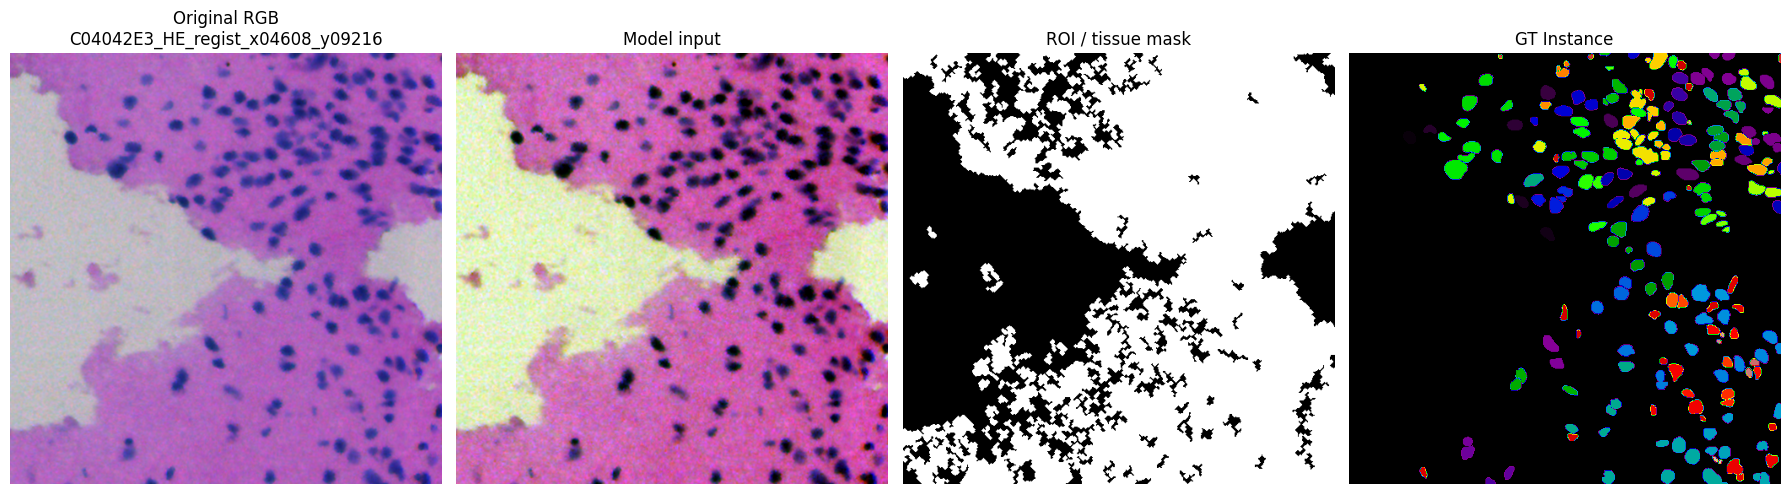

In [8]:

# =========================
# PILIH DATA TUNING + PREVIEW
# =========================
if TUNING_IMAGE_STEM is None:
    tuning_pair = pairs[0]
else:
    stem_to_pair = {p.stem: p for p in pairs}
    if TUNING_IMAGE_STEM not in stem_to_pair:
        raise KeyError(
            f"TUNING_IMAGE_STEM={TUNING_IMAGE_STEM!r} tidak ditemukan. "
            f"Contoh stem yang tersedia: {list(stem_to_pair)[:5]}"
        )
    tuning_pair = stem_to_pair[TUNING_IMAGE_STEM]

tuning_raw = load_image_any(tuning_pair.image_path)
tuning_gt = load_instance_mask(tuning_pair.mask_path)
tuning_prepared = prepare_stardist_input(tuning_raw)

run_config = {
    "image_dir": str(IMAGE_DIR),
    "mask_dir": str(MASK_DIR),
    "output_root": str(OUTPUT_ROOT),
    "model_name": MODEL_NAME,
    "model_dir": str(MODEL_DIR),
    "model_backend": model_backend,
    "tuning_image_stem": tuning_pair.stem,
    "default_prob_threshold": float(default_prob),
    "default_nms_threshold": float(default_nms),
    "grid_search_mode": GRID_SEARCH_MODE,
    "grid_coarse_values": GRID_COARSE_VALUES,
    "grid_full_values": GRID_FULL_VALUES,
    "grid_fine_radius": GRID_FINE_RADIUS,
    "grid_fine_step": GRID_FINE_STEP,
    "topk_fine_seeds": TOPK_FINE_SEEDS,
    "topk_full_eval": TOPK_FULL_EVAL,
    "f1_thresholds": F1_THRESHOLDS,
    "normalize_percentile": bool(NORMALIZE_PERCENTILE),
    "use_tissue_mask": bool(USE_TISSUE_MASK),
    "mask_outside_roi": bool(MASK_OUTSIDE_ROI),
    "apply_roi_before_nms": bool(APPLY_ROI_BEFORE_NMS),
    "axes": STARDIST_AXES,
    "n_tiles": list(N_TILES) if N_TILES is not None else None,
    "use_gpu": bool(USE_GPU),
    "require_gpu_when_enabled": bool(REQUIRE_GPU_WHEN_ENABLED),
    "gpu_device_index": int(GPU_DEVICE_INDEX),
    "tf_memory_growth": bool(TF_MEMORY_GROWTH),
    "tf_enable_xla": bool(TF_ENABLE_XLA),
    "tf_enable_mixed_precision": bool(TF_ENABLE_MIXED_PRECISION),
    "grid_search_use_cached_network_output": bool(GRID_SEARCH_USE_CACHED_NETWORK_OUTPUT),
    "max_grid_candidates": int(MAX_GRID_CANDIDATES),
}
save_json(RUN_CONFIG_PATH, run_config)

print("Tuning image :", tuning_pair.stem)
print("Image path   :", tuning_pair.image_path)
print("Mask path    :", tuning_pair.mask_path)
print("Default prob :", default_prob)
print("Default nms  :", default_nms)
print("GT cells     :", int(tuning_gt.max()))

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(normalize_for_display(tuning_prepared["image_rgb"]))
axes[0].set_title(f"Original RGB\n{tuning_pair.stem}")
axes[0].axis("off")

axes[1].imshow(normalize_for_display(tuning_prepared["image_model"]))
axes[1].set_title("Model input")
axes[1].axis("off")

axes[2].imshow(tuning_prepared["roi_mask"], cmap="gray")
axes[2].set_title("ROI / tissue mask")
axes[2].axis("off")

axes[3].imshow(tuning_gt, cmap="nipy_spectral")
axes[3].set_title("GT Instance")
axes[3].axis("off")

plt.tight_layout()
plt.show()


In [9]:

# =========================
# GRID SEARCH PADA 1 PASANGAN TUNING
# Tahap 1 : evaluasi ringan
# Tahap 2 : full evaluation hanya untuk kandidat terbaik
# =========================
def round_unique(values: Iterable[float], ndigits: int = 4) -> List[float]:
    out = sorted({round(float(v), ndigits) for v in values})
    return out

def sort_combos_around_defaults(
    combos: Sequence[Tuple[float, float]],
    center_prob: float,
    center_nms: float,
) -> List[Tuple[float, float]]:
    return sorted(
        [(float(p), float(n)) for p, n in combos],
        key=lambda x: (abs(x[0] - center_prob), abs(x[1] - center_nms), x[0], x[1]),
    )

def build_stage1_combos(default_prob: float, default_nms: float) -> List[Tuple[float, float]]:
    if GRID_SEARCH_MODE == "coarse_to_fine":
        combos = list(itertools.product(GRID_COARSE_VALUES, GRID_COARSE_VALUES))
        return sort_combos_around_defaults(combos, default_prob, default_nms)

    if GRID_SEARCH_MODE == "full_safe_0_1":
        combos = list(itertools.product(GRID_FULL_VALUES, GRID_FULL_VALUES))
        return sort_combos_around_defaults(combos, default_prob, default_nms)

    raise ValueError(f"GRID_SEARCH_MODE tidak dikenal: {GRID_SEARCH_MODE}")

def build_fine_combos_from_topk(
    stage1_df: pd.DataFrame,
    default_prob: float,
    default_nms: float,
) -> List[Tuple[float, float]]:
    success = stage1_df.loc[stage1_df["status"] == "ok"].copy()
    if success.empty:
        return []

    success = success.sort_values(
        by=["Primary_Score_Mean", "F1", "IoU", "Precision", "Recall"],
        ascending=False,
    ).reset_index(drop=True)

    seed_rows = success.head(int(TOPK_FINE_SEEDS))
    combos: List[Tuple[float, float]] = []

    for _, row in seed_rows.iterrows():
        p_center = float(row["prob_thresh"])
        n_center = float(row["nms_thresh"])
        p_vals = round_unique(np.arange(max(0.05, p_center - GRID_FINE_RADIUS), min(0.95, p_center + GRID_FINE_RADIUS) + 1e-9, GRID_FINE_STEP), ndigits=4)
        n_vals = round_unique(np.arange(max(0.0, n_center - GRID_FINE_RADIUS), min(1.0, n_center + GRID_FINE_RADIUS) + 1e-9, GRID_FINE_STEP), ndigits=4)
        combos.extend(list(itertools.product(p_vals, n_vals)))

    combos = sort_combos_around_defaults(set(combos), default_prob, default_nms)
    existing = {
        (round(float(r["prob_thresh"]), 4), round(float(r["nms_thresh"]), 4))
        for _, r in success.iterrows()
    }
    return [
        (float(p), float(n))
        for p, n in combos
        if (round(float(p), 4), round(float(n), 4)) not in existing
    ]

def save_progress_table(df: pd.DataFrame, csv_path: Path) -> None:
    csv_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(csv_path, index=False)

def run_light_grid_search(
    stage_name: str,
    combos: Sequence[Tuple[float, float]],
    tuning_gt: np.ndarray,
    tuning_prepared: Dict[str, np.ndarray],
    tuning_prediction_cache: Tuple[np.ndarray, ...],
) -> pd.DataFrame:
    stage_csv = GRID_DIR / f"{stage_name}_light_results.csv"

    existing_records: List[Dict[str, Any]] = []
    done_keys: set[Tuple[float, float]] = set()

    if GRID_SEARCH_RESUME and stage_csv.exists():
        prev_df = pd.read_csv(stage_csv)
        existing_records = prev_df.to_dict("records")
        done_keys = {
            (round(float(r["prob_thresh"]), 4), round(float(r["nms_thresh"]), 4))
            for _, r in prev_df.iterrows()
        }
        print(f"[resume] {stage_name}: memuat {len(done_keys)} kombinasi yang sudah ada.")

    records = list(existing_records)
    remaining = [
        (float(p), float(n))
        for p, n in combos
        if (round(float(p), 4), round(float(n), 4)) not in done_keys
    ]

    print(f"{stage_name} - jumlah kombinasi total    :", len(combos))
    print(f"{stage_name} - jumlah kombinasi tersisa  :", len(remaining))

    pbar = tqdm(remaining, total=len(remaining), desc=f"{stage_name} StarDist")
    for idx, (prob_thresh, nms_thresh) in enumerate(pbar, start=1):
        params = {"prob_thresh": float(prob_thresh), "nms_thresh": float(nms_thresh)}
        combo_t0 = time.perf_counter()

        candidate_count = estimate_candidate_count(
            tuning_prediction_cache,
            prob_thresh=float(prob_thresh),
        )

        if candidate_count > int(MAX_GRID_CANDIDATES):
            record = {
                "stage": stage_name,
                "prob_thresh": float(prob_thresh),
                "nms_thresh": float(nms_thresh),
                "candidate_count": int(candidate_count),
                "Primary_Score_Mean": 0.0,
                "Precision": 0.0,
                "Recall": 0.0,
                "F1": 0.0,
                "IoU": 0.0,
                "N_GT": int(tuning_gt.max()),
                "N_Pred": 0,
                "Count_Error": -int(tuning_gt.max()),
                "elapsed_sec": round(float(time.perf_counter() - combo_t0), 6),
                "status": "skip_candidate_overflow",
            }
            records.append(record)
        else:
            try:
                pred_inst, _, aux = run_stardist_inference(
                    model=model,
                    params=params,
                    prepared_input=tuning_prepared,
                    prediction_cache=tuning_prediction_cache,
                )
                metrics = evaluate_grid_candidate(tuning_gt, pred_inst)

                record = dict(params)
                record.update({
                    "stage": stage_name,
                    "candidate_count": int(aux["candidate_count"]),
                    "forward_seconds": float(aux["forward_seconds"]),
                    "postprocess_seconds": float(aux["postprocess_seconds"]),
                    "Primary_Score_Mean": metrics["Primary_Score_Mean"],
                    "Precision": metrics["Precision"],
                    "Recall": metrics["Recall"],
                    "F1": metrics["F1"],
                    "IoU": metrics["IoU"],
                    "N_GT": metrics["N_GT"],
                    "N_Pred": metrics["N_Pred"],
                    "Count_Error": metrics["Count_Error"],
                    "elapsed_sec": round(float(time.perf_counter() - combo_t0), 6),
                    "status": "ok",
                })
                records.append(record)
            except Exception as exc:
                record = {
                    "stage": stage_name,
                    "prob_thresh": float(prob_thresh),
                    "nms_thresh": float(nms_thresh),
                    "candidate_count": int(candidate_count),
                    "Primary_Score_Mean": 0.0,
                    "Precision": 0.0,
                    "Recall": 0.0,
                    "F1": 0.0,
                    "IoU": 0.0,
                    "N_GT": int(tuning_gt.max()),
                    "N_Pred": 0,
                    "Count_Error": -int(tuning_gt.max()),
                    "elapsed_sec": round(float(time.perf_counter() - combo_t0), 6),
                    "status": f"error: {exc}",
                }
                records.append(record)

        if idx % int(GRID_SEARCH_FLUSH_EVERY) == 0:
            save_progress_table(pd.DataFrame(records), stage_csv)

    df = pd.DataFrame(records)
    if not df.empty:
        df = df.sort_values(
            by=["Primary_Score_Mean", "F1", "IoU", "Precision", "Recall"],
            ascending=False,
        ).reset_index(drop=True)
        save_progress_table(df, stage_csv)
    return df

def run_full_eval_topk(
    combined_light_df: pd.DataFrame,
    tuning_gt: np.ndarray,
    tuning_prepared: Dict[str, np.ndarray],
    tuning_prediction_cache: Tuple[np.ndarray, ...],
) -> pd.DataFrame:
    full_csv = GRID_DIR / "topk_full_evaluation.csv"

    success = combined_light_df.loc[combined_light_df["status"] == "ok"].copy()
    if success.empty:
        return pd.DataFrame()

    success = success.sort_values(
        by=["Primary_Score_Mean", "F1", "IoU", "Precision", "Recall"],
        ascending=False,
    ).reset_index(drop=True)

    topk = success.head(int(TOPK_FULL_EVAL)).copy()
    records: List[Dict[str, Any]] = []

    for _, row in tqdm(topk.iterrows(), total=len(topk), desc="Full eval top-K"):
        params = {
            "prob_thresh": float(row["prob_thresh"]),
            "nms_thresh": float(row["nms_thresh"]),
        }
        eval_t0 = time.perf_counter()
        pred_inst, _, aux = run_stardist_inference(
            model=model,
            params=params,
            prepared_input=tuning_prepared,
            prediction_cache=tuning_prediction_cache,
        )
        metrics = evaluate_case(tuning_gt, pred_inst, thresholds=F1_THRESHOLDS)

        rec = dict(params)
        rec.update(metrics)
        rec.update({
            "stage": "topk_full_eval",
            "candidate_count": int(aux["candidate_count"]),
            "forward_seconds": float(aux["forward_seconds"]),
            "postprocess_seconds": float(aux["postprocess_seconds"]),
            "elapsed_sec": round(float(time.perf_counter() - eval_t0), 6),
            "status": "ok",
        })
        records.append(rec)

    full_df = pd.DataFrame(records).sort_values(
        by=[
            "Full_Composite_Score",
            "Primary_Score_Mean",
            "AJI",
            "PQ",
            "DQ",
            "SQ",
            "F1",
            "IoU",
            "Precision",
            "Recall",
        ],
        ascending=False,
    ).reset_index(drop=True)

    full_df.to_csv(full_csv, index=False)
    return full_df

# 1x forward pass tuning image
cache_t0 = time.perf_counter()
tuning_prediction_cache = compute_stardist_prediction_cache(
    model=model,
    prepared_input=tuning_prepared,
)
cache_forward_seconds = time.perf_counter() - cache_t0

print(f"Cache forward pass tuning image aktif. Waktu 1x forward pass: {cache_forward_seconds:.3f} detik")

# Candidate statistics untuk membantu diagnosis
prob_map = np.asarray(tuning_prediction_cache[0])
candidate_probe = []
for thr in [0.0, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7]:
    candidate_probe.append({
        "prob_thresh": thr,
        "candidate_count": estimate_candidate_count(tuning_prediction_cache, thr),
    })
candidate_probe_df = pd.DataFrame(candidate_probe)
display(candidate_probe_df)

# Tahap 1
stage1_combos = build_stage1_combos(default_prob=default_prob, default_nms=default_nms)
stage1_df = run_light_grid_search(
    stage_name="stage1",
    combos=stage1_combos,
    tuning_gt=tuning_gt,
    tuning_prepared=tuning_prepared,
    tuning_prediction_cache=tuning_prediction_cache,
)

# Tahap 1b (fine search) bila diminta
light_tables = [stage1_df]
if GRID_SEARCH_MODE == "coarse_to_fine":
    fine_combos = build_fine_combos_from_topk(stage1_df, default_prob=default_prob, default_nms=default_nms)
    print("Jumlah kombinasi fine search:", len(fine_combos))
    if fine_combos:
        stage2_df = run_light_grid_search(
            stage_name="stage2_fine",
            combos=fine_combos,
            tuning_gt=tuning_gt,
            tuning_prepared=tuning_prepared,
            tuning_prediction_cache=tuning_prediction_cache,
        )
        light_tables.append(stage2_df)

light_df = (
    pd.concat(light_tables, ignore_index=True)
    .drop_duplicates(subset=["prob_thresh", "nms_thresh"], keep="last")
    .sort_values(by=["Primary_Score_Mean", "F1", "IoU", "Precision", "Recall"], ascending=False)
    .reset_index(drop=True)
)

light_df.to_csv(GRID_DIR / "all_light_grid_results.csv", index=False)

if light_df.empty or (light_df["status"] == "ok").sum() == 0:
    raise RuntimeError(
        "Grid search selesai, tetapi tidak ada kombinasi yang berhasil. "
        "Coba naikkan MAX_GRID_CANDIDATES, pakai tissue mask, atau mulai dari coarse_to_fine."
    )

# Tahap 2: metrik lengkap hanya untuk top-K
full_eval_df = run_full_eval_topk(
    combined_light_df=light_df,
    tuning_gt=tuning_gt,
    tuning_prepared=tuning_prepared,
    tuning_prediction_cache=tuning_prediction_cache,
)

if full_eval_df.empty:
    best_params = {
        "prob_thresh": float(light_df.iloc[0]["prob_thresh"]),
        "nms_thresh": float(light_df.iloc[0]["nms_thresh"]),
    }
    best_metrics = None
else:
    best_params = {
        "prob_thresh": float(full_eval_df.iloc[0]["prob_thresh"]),
        "nms_thresh": float(full_eval_df.iloc[0]["nms_thresh"]),
    }
    best_metrics = full_eval_df.iloc[0].to_dict()

save_json(GRID_DIR / "best_params.json", best_params)
if best_metrics is not None:
    save_json(GRID_DIR / "best_metrics.json", best_metrics)

# Rekomputasi hasil terbaik untuk tuning panel
best_pred_inst, _, best_aux = run_stardist_inference(
    model=model,
    params=best_params,
    prepared_input=tuning_prepared,
    prediction_cache=tuning_prediction_cache,
)
best_eval = evaluate_case(tuning_gt, best_pred_inst, thresholds=F1_THRESHOLDS)

# simpan xlsx
grid_xlsx = GRID_DIR / "grid_search_results.xlsx"
with pd.ExcelWriter(grid_xlsx, engine="openpyxl") as writer:
    light_df.to_excel(writer, sheet_name="light_grid_all", index=False)
    if not full_eval_df.empty:
        full_eval_df.to_excel(writer, sheet_name="topk_full_eval", index=False)
    pd.DataFrame([best_params]).to_excel(writer, sheet_name="best_params", index=False)
    pd.DataFrame([best_eval]).to_excel(writer, sheet_name="best_metrics", index=False)

print("Best params:", best_params)
display(light_df.head(10))
if not full_eval_df.empty:
    display(full_eval_df.head(10))


Cache forward pass tuning image aktif. Waktu 1x forward pass: 0.725 detik


,prob_thresh,candidate_count
0,0.00,40539
1,0.05,10062
2,0.10,8414
3,0.20,6503
4,0.30,5065
5,0.50,2611
6,0.70,693


[resume] stage1: memuat 121 kombinasi yang sudah ada.
stage1 - jumlah kombinasi total    : 121
stage1 - jumlah kombinasi tersisa  : 0


stage1 StarDist: 0it [00:00, ?it/s]
Full eval top-K: 100%|██████████| 10/10 [00:49<00:00,  4.95s/it]


Best params: {'prob_thresh': 0.1, 'nms_thresh': 0.6}


,prob_thresh,nms_thresh,stage,candidate_count,forward_seconds,postprocess_seconds,Primary_Score_Mean,Precision,Recall,F1,IoU,N_GT,N_Pred,Count_Error,elapsed_sec,status
0,0.1,0.6,stage1,8414,0.0,2.260619,0.842065,0.871252,0.863660,0.867440,0.765910,222,198,-24,2.380114,ok
1,0.1,0.7,stage1,8414,0.0,2.576049,0.841557,0.863235,0.870784,0.866993,0.765215,222,222,0,2.702883,ok
2,0.1,0.5,stage1,8414,0.0,2.134778,0.840924,0.876451,0.856566,0.866395,0.764282,222,186,-36,2.259565,ok
3,0.1,0.8,stage1,8414,0.0,3.363817,0.839003,0.846573,0.883382,0.864586,0.761472,222,292,70,3.483649,ok
4,0.1,0.4,stage1,8414,0.0,2.037109,0.835908,0.880858,0.843663,0.861859,0.757252,222,175,-47,2.163217,ok
5,0.2,0.7,stage1,6503,0.0,2.223926,0.835456,0.875327,0.848188,0.861544,0.756766,222,195,-27,2.345647,ok
6,0.2,0.8,stage1,6503,0.0,5.263800,0.835419,0.868541,0.854732,0.861581,0.756823,222,227,5,5.407046,ok
7,0.1,0.3,stage1,8414,0.0,1.992598,0.834486,0.881570,0.840544,0.860568,0.755261,222,173,-49,2.111503,ok
8,0.2,0.6,stage1,6503,0.0,3.722864,0.833637,0.879165,0.841370,0.859853,0.754159,222,183,-39,3.844397,ok
9,0.2,0.5,stage1,6503,0.0,3.120462,0.831182,0.883876,0.832717,0.857534,0.750599,222,171,-51,3.281012,ok


,prob_thresh,nms_thresh,Precision,Recall,F1,IoU,Dice,Specificity,MCC,TP_pixels,FP_pixels,FN_pixels,TN_pixels,AJI,PQ,DQ,SQ,TP_objects,FP_objects,FN_objects,N_GT,N_Pred,Count_Error,Abs_Count_Error,Rel_Count_Err,Over_Seg_Rate,Under_Seg_Rate,Split_GT_Count,Merge_Pred_Count,Unmatched_GT_Count,Unmatched_Pred_Count,F1@0.3,F1@0.5,F1@0.6,F1@0.7,F1@0.8,F1@0.9,GT_Area_Mean,GT_Area_Std,GT_Area_Med,GT_Circ_Mean,GT_Ecc_Mean,GT_Diam_Mean,Pred_Area_Mean,Pred_Area_Std,Pred_Area_Med,Pred_Circ_Mean,Pred_Ecc_Mean,Pred_Diam_Mean,AbsDiff_Area_Mean,AbsDiff_Area_Std,AbsDiff_Area_Med,AbsDiff_Circ_Mean,AbsDiff_Ecc_Mean,AbsDiff_Diam_Mean,Primary_Score_Mean,Full_Composite_Score,stage,candidate_count,forward_seconds,postprocess_seconds,elapsed_sec,status
0,0.1,0.6,0.871252,0.863660,0.867440,0.765910,0.867440,0.981808,0.848649,28246,4174,4459,225265,0.689102,0.608712,0.804762,0.756388,169,29,53,222,198,-24,24,-0.108108,0.207207,0.252252,46,56,53,29,0.876190,0.804762,0.728571,0.585714,0.338095,0.023810,147.31982,77.498919,145.0,0.925617,0.699189,13.158629,163.737374,80.684018,165.0,0.911093,0.669022,13.913968,16.417554,3.185099,20.0,0.014524,0.030167,0.755339,0.842065,0.756797,topk_full_eval,8414,0.0,4.485199,4.832902,ok
1,0.1,0.7,0.863235,0.870784,0.866993,0.765215,0.866993,0.980335,0.847950,28479,4512,4226,224927,0.682916,0.577828,0.765766,0.754575,170,52,52,222,222,0,0,0.000000,0.279279,0.301802,62,67,52,52,0.828829,0.765766,0.689189,0.554054,0.319820,0.022523,147.31982,77.498919,145.0,0.925617,0.699189,13.158629,148.608108,87.926487,152.5,1.169572,0.686886,12.941716,1.288288,10.427568,7.5,0.243955,0.012303,0.216913,0.841557,0.756702,topk_full_eval,8414,0.0,4.933676,5.272214,ok
2,0.1,0.5,0.876451,0.856566,0.866395,0.764282,0.866395,0.982788,0.847672,28014,3949,4691,225490,0.688460,0.621436,0.818627,0.759119,167,19,55,222,186,-36,36,-0.162162,0.157658,0.238739,35,53,55,19,0.872549,0.818627,0.750000,0.602941,0.348039,0.024510,147.31982,77.498919,145.0,0.925617,0.699189,13.158629,171.844086,75.945881,169.5,0.902198,0.659874,14.407148,24.524266,1.553038,24.5,0.023419,0.039315,1.248519,0.840924,0.754666,topk_full_eval,8414,0.0,4.164679,4.488185,ok
3,0.1,0.4,0.880858,0.843663,0.861859,0.757252,0.861859,0.983734,0.842907,27592,3732,5113,225707,0.687727,0.636047,0.836272,0.760574,166,9,56,222,175,-47,47,-0.211712,0.126126,0.225225,28,50,56,9,0.881612,0.836272,0.765743,0.624685,0.357683,0.025189,147.31982,77.498919,145.0,0.925617,0.699189,13.158629,178.994286,72.263288,177.0,0.923674,0.653418,14.785650,31.674466,5.235631,32.0,0.001943,0.045771,1.627021,0.835908,0.752416,topk_full_eval,8414,0.0,3.994362,4.310997,ok
4,0.1,0.3,0.881570,0.840544,0.860568,0.755261,0.860568,0.983904,0.841542,27490,3693,5215,225746,0.685566,0.635618,0.835443,0.760815,165,8,57,222,173,-49,49,-0.220721,0.112613,0.220721,25,49,57,8,0.875949,0.835443,0.759494,0.622785,0.359494,0.025316,147.31982,77.498919,145.0,0.925617,0.699189,13.158629,180.248555,71.772292,181.0,0.928494,0.651665,14.846028,32.928735,5.726627,36.0,0.002877,0.047524,1.687399,0.834486,0.750318,topk_full_eval,8414,0.0,3.809067,4.124810,ok
5,0.2,0.7,0.875327,0.848188,0.861544,0.756766,0.861544,0.982780,0.842298,27740,3951,4965,225488,0.679341,0.599027,0.791367,0.756952,165,30,57,222,195,-27,27,-0.121622,0.198198,0.256757,44,57,57,30,0.848921,0.791367,0.719424,0.580336,0.330935,0.023981,147.31982,77.498919,145.0,0.925617,0.699189,13.158629,162.517949,83.579371,165.0,1.205207,0.674916,13.747028,15.198129,6.080452,20.0,0.279590,0.024273,0.588399,0.835456,0.748231,topk_full_eval,6503,0.0,4.501343,4.826826,ok
6,0.2,0.6,0.879165,0.841370,0.859853,0.754159,0.859853,0.983516,0.840638,27517,3782,5188,225657,0.680468,0.611999,0.804938,0.760305,163,20,59,222,183,-39,39,-0.175676,0.148649,0.229730,33,51,59,20,0.869136,0.804938,0.740741,0.597531,0.340741,0.024691,147.31982,77.498919,145.0,0.925617,0.699189,13.158629,171.032787,78.655776,171.0,0.913699,0.669088,14.301801,23.712967,1.156857,26.0,0.011918,0.030101,1.143172,0.833637,0.746540,

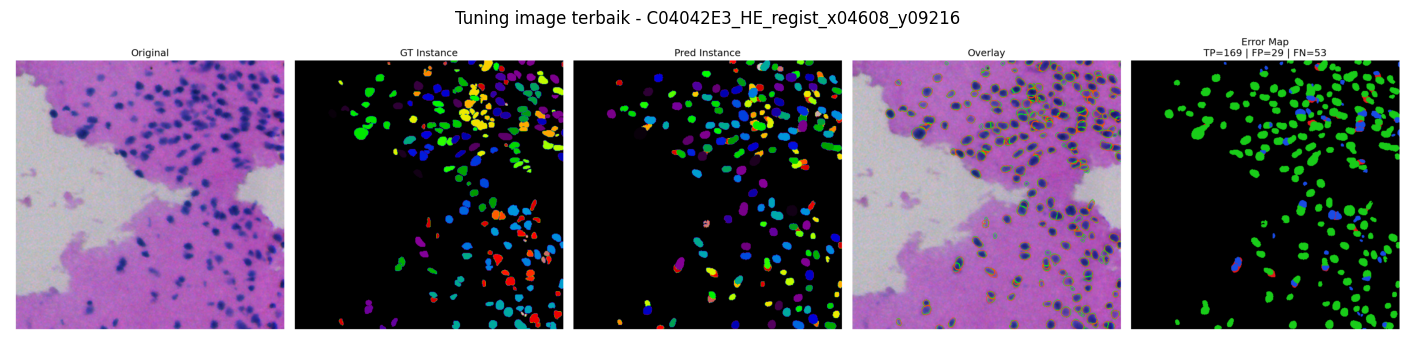

Best tuning metrics:


,Precision,Recall,F1,IoU,Dice,Specificity,MCC,TP_pixels,FP_pixels,FN_pixels,TN_pixels,AJI,PQ,DQ,SQ,TP_objects,FP_objects,FN_objects,N_GT,N_Pred,Count_Error,Abs_Count_Error,Rel_Count_Err,Over_Seg_Rate,Under_Seg_Rate,Split_GT_Count,Merge_Pred_Count,Unmatched_GT_Count,Unmatched_Pred_Count,F1@0.3,F1@0.5,F1@0.6,F1@0.7,F1@0.8,F1@0.9,GT_Area_Mean,GT_Area_Std,GT_Area_Med,GT_Circ_Mean,GT_Ecc_Mean,GT_Diam_Mean,Pred_Area_Mean,Pred_Area_Std,Pred_Area_Med,Pred_Circ_Mean,Pred_Ecc_Mean,Pred_Diam_Mean,AbsDiff_Area_Mean,AbsDiff_Area_Std,AbsDiff_Area_Med,AbsDiff_Circ_Mean,AbsDiff_Ecc_Mean,AbsDiff_Diam_Mean,Primary_Score_Mean,Full_Composite_Score
0,0.871252,0.86366,0.86744,0.76591,0.86744,0.981808,0.848649,28246,4174,4459,225265,0.689102,0.608712,0.804762,0.756388,169,29,53,222,198,-24,24,-0.108108,0.207207,0.252252,46,56,53,29,0.87619,0.804762,0.728571,0.585714,0.338095,0.02381,147.31982,77.498919,145.0,0.925617,0.699189,13.158629,163.737374,80.684018,165.0,0.911093,0.669022,13.913968,16.417554,3.185099,20.0,0.014524,0.030167,0.755339,0.842065,0.756797


In [10]:

# =========================
# PANEL HASIL TERBAIK PADA TUNING IMAGE
# =========================
best_panel_dir = GRID_DIR / "best_tuning_visual"
best_panel_dir.mkdir(parents=True, exist_ok=True)
save_case_visuals(
    image=best_aux["image_rgb"],
    gt_inst=tuning_gt,
    pred_inst=best_pred_inst,
    output_dir=best_panel_dir,
    stem=tuning_pair.stem,
)

best_panel_path = best_panel_dir / f"{tuning_pair.stem}_panel.png"
if best_panel_path.exists():
    plt.figure(figsize=(18, 5))
    plt.imshow(io.imread(str(best_panel_path)))
    plt.axis("off")
    plt.title(f"Tuning image terbaik - {tuning_pair.stem}")
    plt.show()

print("Best tuning metrics:")
display(pd.DataFrame([best_eval]))


In [11]:

# =========================
# INFERENSI 30 GAMBAR + EVALUASI + PENYIMPANAN PER GAMBAR
# =========================
all_rows: List[Dict[str, Any]] = []
failed_cases: List[Dict[str, str]] = []

for pair in tqdm(pairs, total=len(pairs), desc="Inferensi semua gambar"):
    raw_image = load_image_any(pair.image_path)
    gt_inst = load_instance_mask(pair.mask_path)
    prepared_input = prepare_stardist_input(raw_image)

    case_dir = PER_IMAGE_DIR / pair.stem
    case_dir.mkdir(parents=True, exist_ok=True)

    try:
        infer_t0 = time.perf_counter()
        pred_inst, _, aux = run_stardist_inference(
            model=model,
            params=best_params,
            prepared_input=prepared_input,
        )
        total_inference_seconds = time.perf_counter() - infer_t0

        metrics = evaluate_case(gt_inst, pred_inst, thresholds=F1_THRESHOLDS)
        metrics.update({
            "image_id": pair.stem,
            "image_path": str(pair.image_path),
            "mask_path": str(pair.mask_path),
            "Inference_Seconds": round(float(total_inference_seconds), 6),
            "Forward_Seconds": round(float(aux["forward_seconds"]), 6),
            "Postprocess_Seconds": round(float(aux["postprocess_seconds"]), 6),
            "Candidate_Count": int(aux["candidate_count"]),
            "best_prob_thresh": float(best_params["prob_thresh"]),
            "best_nms_thresh": float(best_params["nms_thresh"]),
        })
        all_rows.append(metrics)

        tifffile.imwrite(str(case_dir / f"{pair.stem}_pred_instance.tif"), pred_inst.astype(np.uint32))
        save_binary_png(case_dir / f"{pair.stem}_pred_binary.png", to_binary(pred_inst))
        pd.DataFrame([metrics]).to_csv(case_dir / f"{pair.stem}_metrics.csv", index=False)
        save_json(case_dir / f"{pair.stem}_metrics.json", metrics)
        save_case_visuals(aux["image_rgb"], gt_inst, pred_inst, case_dir, pair.stem)

    except Exception as exc:
        failed_cases.append({
            "image_id": pair.stem,
            "image_path": str(pair.image_path),
            "mask_path": str(pair.mask_path),
            "error": str(exc),
        })

metrics_df = pd.DataFrame(all_rows)
failed_df = pd.DataFrame(failed_cases)

print("Jumlah inferensi berhasil:", len(metrics_df))
print("Jumlah inferensi gagal   :", len(failed_df))

if not failed_df.empty:
    display(failed_df.head())


Inferensi semua gambar: 100%|██████████| 10/10 [01:25<00:00,  8.52s/it]

Jumlah inferensi berhasil: 10
Jumlah inferensi gagal   : 0


In [12]:

# =========================
# REKAP CSV / EXCEL
# =========================
if metrics_df.empty:
    raise RuntimeError("Tidak ada hasil inferensi yang berhasil, sehingga tidak bisa dibuat rekap.")

id_cols = ["image_id", "image_path", "mask_path"]
primary_cols = [
    "Precision", "Recall", "F1", "IoU", "Dice",
    "AJI", "PQ", "DQ", "SQ",
    "Primary_Score_Mean", "Full_Composite_Score",
    "Inference_Seconds", "Forward_Seconds", "Postprocess_Seconds",
    "Candidate_Count",
    "N_GT", "N_Pred", "Count_Error", "Abs_Count_Error",
    "Rel_Count_Err", "Over_Seg_Rate", "Under_Seg_Rate",
    "Split_GT_Count", "Merge_Pred_Count",
    "Specificity", "MCC",
]
threshold_cols = sorted([c for c in metrics_df.columns if c.startswith("F1@")], key=lambda x: float(x.split("@")[1]))
other_cols = [c for c in metrics_df.columns if c not in id_cols + primary_cols + threshold_cols]
ordered_cols = [c for c in id_cols + primary_cols + threshold_cols + other_cols if c in metrics_df.columns]
metrics_df = metrics_df[ordered_cols].sort_values("image_id").reset_index(drop=True)

numeric_cols = metrics_df.select_dtypes(include=[np.number]).columns.tolist()
mean_row = metrics_df[numeric_cols].mean().to_dict()
std_row = metrics_df[numeric_cols].std(ddof=1).fillna(0).to_dict()

mean_df = pd.DataFrame([mean_row]); mean_df.insert(0, "stat", "mean")
std_df = pd.DataFrame([std_row]); std_df.insert(0, "stat", "std")
aggregate_df = pd.concat([mean_df, std_df], axis=0, ignore_index=True)

per_image_csv = SUMMARY_DIR / "per_image_metrics.csv"
per_image_xlsx = SUMMARY_DIR / "per_image_metrics.xlsx"
agg_csv = SUMMARY_DIR / "aggregate_mean_std.csv"
agg_xlsx = SUMMARY_DIR / "aggregate_mean_std.xlsx"
failed_csv = SUMMARY_DIR / "failed_cases.csv"

metrics_df.to_csv(per_image_csv, index=False)
aggregate_df.to_csv(agg_csv, index=False)
failed_df.to_csv(failed_csv, index=False)

with pd.ExcelWriter(per_image_xlsx, engine="openpyxl") as writer:
    metrics_df.to_excel(writer, sheet_name="per_image", index=False)

with pd.ExcelWriter(agg_xlsx, engine="openpyxl") as writer:
    aggregate_df.to_excel(writer, sheet_name="aggregate", index=False)

print("Rekap tersimpan:")
print(" -", per_image_csv)
print(" -", per_image_xlsx)
print(" -", agg_csv)
print(" -", agg_xlsx)
print(" -", failed_csv)

display(metrics_df.head())
display(aggregate_df)


Rekap tersimpan:
 - /data/work/InferencePretrained/StarDist_Fast_GridSearch_V5/03_ringkasan_rata_rata_metrik/per_image_metrics.csv
 - /data/work/InferencePretrained/StarDist_Fast_GridSearch_V5/03_ringkasan_rata_rata_metrik/per_image_metrics.xlsx
 - /data/work/InferencePretrained/StarDist_Fast_GridSearch_V5/03_ringkasan_rata_rata_metrik/aggregate_mean_std.csv
 - /data/work/InferencePretrained/StarDist_Fast_GridSearch_V5/03_ringkasan_rata_rata_metrik/aggregate_mean_std.xlsx
 - /data/work/InferencePretrained/StarDist_Fast_GridSearch_V5/03_ringkasan_rata_rata_metrik/failed_cases.csv


,image_id,image_path,mask_path,Precision,Recall,F1,IoU,Dice,AJI,PQ,DQ,SQ,Primary_Score_Mean,Full_Composite_Score,Inference_Seconds,Forward_Seconds,Postprocess_Seconds,Candidate_Count,N_GT,N_Pred,Count_Error,Abs_Count_Error,Rel_Count_Err,Over_Seg_Rate,Under_Seg_Rate,Split_GT_Count,Merge_Pred_Count,Specificity,MCC,F1@0.3,F1@0.5,F1@0.6,F1@0.7,F1@0.8,F1@0.9,TP_pixels,FP_pixels,FN_pixels,TN_pixels,TP_objects,FP_objects,FN_objects,Unmatched_GT_Count,Unmatched_Pred_Count,GT_Area_Mean,GT_Area_Std,GT_Area_Med,GT_Circ_Mean,GT_Ecc_Mean,GT_Diam_Mean,Pred_Area_Mean,Pred_Area_Std,Pred_Area_Med,Pred_Circ_Mean,Pred_Ecc_Mean,Pred_Diam_Mean,AbsDiff_Area_Mean,AbsDiff_Area_Std,AbsDiff_Area_Med,AbsDiff_Circ_Mean,AbsDiff_Ecc_Mean,AbsDiff_Diam_Mean,best_prob_thresh,best_nms_thresh
0,C04042E3_HE_regist_x04608_y09216,/data/work/InferencePretrained/Images/C04042E3...,/data/work/InferencePretrained/MaskInstance/C0...,0.871252,0.863660,0.867440,0.765910,0.867440,0.689102,0.608712,0.804762,0.756388,0.842065,0.756797,4.753558,0.210344,4.535196,8414,222,198,-24,24,-0.108108,0.207207,0.252252,46,56,0.981808,0.848649,0.876190,0.804762,0.728571,0.585714,0.338095,0.023810,28246,4174,4459,225265,169,29,53,53,29,147.319820,77.498919,145.0,0.925617,0.699189,13.158629,163.737374,80.684018,165.0,0.911093,0.669022,13.913968,16.417554,3.185099,20.0,0.014524,0.030167,0.755339,0.1,0.6
1,C04042E3_HE_regist_x05632_y09728,/data/work/InferencePretrained/Images/C04042E3...,/data/work/InferencePretrained/MaskInstance/C0...,0.936460,0.781215,0.851822,0.741890,0.851822,0.654805,0.559948,0.755556,0.741107,0.827847,0.723427,5.145329,0.215555,4.920970,8731,244,206,-38,38,-0.155738,0.180328,0.245902,44,60,0.990260,0.832080,0.831111,0.755556,0.697778,0.537778,0.217778,0.017778,31790,2157,8903,219294,170,36,74,74,36,166.774590,107.275435,151.5,0.939641,0.659822,13.833284,164.791262,100.091464,155.0,1.104431,0.662296,13.749033,1.983328,7.183971,3.5,0.164790,0.002474,0.084251,0.1,0.6
2,C04042E3_HE_regist_x07168_y11776,/data/work/InferencePretrained/Images/C04042E3...,/data/work/InferencePretrained/MaskInstance/C0...,0.740462,0.842224,0.788071,0.650262,0.788071,0.591568,0.568572,0.748299,0.759820,0.755255,0.712912,3.690658,0.199853,3.482467,6599,147,147,0,0,0.000000,0.170068,0.183673,25,27,0.969257,0.766384,0.809524,0.748299,0.673469,0.571429,0.326531,0.000000,20824,7299,3901,230120,110,37,37,37,37,168.197279,100.326585,155.0,0.939158,0.671965,13.984430,191.312925,116.039097,178.0,0.861620,0.637850,14.891481,23.115646,15.712512,23.0,0.077538,0.034115,0.907051,0.1,0.6
3,C04042E3_HE_regist_x08192_y05120,/data/work/InferencePretrained/Images/C04042E3...,/data/work/InferencePretrained/MaskInstance/C0...,0.925025,0.804204,0.860394,0.754992,0.860394,0.705742,0.645482,0.864865,0.746339,0.836154,0.775618,4.559536,0.184682,4.366379,9650,189,181,-8,8,-0.042328,0.206349,0.211640,39,40,0.986715,0.837183,0.908108,0.864865,0.772973,0.637838,0.302703,0.021622,35693,2893,8690,214868,160,21,29,29,21,234.830688,121.225588,239.0,0.924964,0.648114,16.619879,213.182320,99.963501,221.0,0.876209,0.614356,15.922197,21.648368,21.262087,18.0,0.048755,0.033758,0.697682,0.1,0.6
4,C04042E3_HE_regist_x08192_y10240,/data/work/InferencePretrained/Images/C04042E3...,/data/work/InferencePretrained/MaskInstance/C0...,0.418835,0.876242,0.566763,0.395442,0.566763,0.367097,0.335759,0.456349,0.735751,0.564321,0.413799,8.936659,0.206332,8.721961,7560,148,356,208,208,1.405405,0.216216,0.189189,32,28,0.903219,0.563964,0.507937,0.456349,0.408730,0.317460,0.103175,0.007937,16936,23500,2392,219316,115,241,33,33,241,130.594595,58.171791,136.0,0.955629,0.674106,12.538327,113.584270,65.344044,96.5,0.922371,0.667906,11.553269,17.010325,7.172253,39.5,0.033258,0.006200,0.985058,0.1,0.6


,stat,Precision,Recall,F1,IoU,Dice,AJI,PQ,DQ,SQ,Primary_Score_Mean,Full_Composite_Score,Inference_Seconds,Forward_Seconds,Postprocess_Seconds,Candidate_Count,N_GT,N_Pred,Count_Error,Abs_Count_Error,Rel_Count_Err,Over_Seg_Rate,Under_Seg_Rate,Split_GT_Count,Merge_Pred_Count,Specificity,MCC,F1@0.3,F1@0.5,F1@0.6,F1@0.7,F1@0.8,F1@0.9,TP_pixels,FP_pixels,FN_pixels,TN_pixels,TP_objects,FP_objects,FN_objects,Unmatched_GT_Count,Unmatched_Pred_Count,GT_Area_Mean,GT_Area_Std,GT_Area_Med,GT_Circ_Mean,GT_Ecc_Mean,GT_Diam_Mean,Pred_Area_Mean,Pred_Area_Std,Pred_Area_Med,Pred_Circ_Mean,Pred_Ecc_Mean,Pred_Diam_Mean,AbsDiff_Area_Mean,AbsDiff_Area_Std,AbsDiff_Area_Med,AbsDiff_Circ_Mean,AbsDiff_Ecc_Mean,AbsDiff_Diam_Mean,best_prob_thresh,best_nms_thresh
0,mean,0.846652,0.790313,0.799223,0.674553,0.799223,0.611285,0.531148,0.725076,0.729108,0.777685,0.683473,5.267145,0.228743,5.027415,7339.400000,178.900000,180.200000,1.300000,40.300000,0.041350,0.175399,0.208888,28.900000,35.000000,0.979160,0.783933,0.819766,0.725076,0.627489,0.479707,0.220271,0.012670,25755.500000,4893.300000,7931.800000,223563.400000,129.800000,50.400000,49.100000,49.100000,50.400000,184.464624,101.486757,181.850000,0.928142,0.673642,14.609087,177.094223,91.584449,172.300000,0.916011,0.669611,14.382402,22.167399,18.711988,24.150000,0.077186,0.017947,0.818447,0.1,6.000000e-01
1,std,0.166524,0.109123,0.097750,0.122624,0.097750,0.103892,0.113408,0.133785,0.041741,0.090410,0.113794,2.054119,0.062005,2.086903,2397.445455,60.548328,79.418442,74.290795,60.962739,0.483625,0.070403,0.070681,12.278708,14.290634,0.027867,0.092504,0.115204,0.133785,0.157628,0.165488,0.114371,0.010474,9629.111927,6810.001339,5805.153875,12351.212007,47.669697,68.197752,25.361607,25.361607,68.197752,38.071640,23.860591,38.140857,0.015491,0.017985,1.490717,28.656786,15.185584,34.587409,0.095741,0.026498,1.266986,19.515073,13.713773,19.405111,0.055212,0.011758,0.734198,0.0,1.170278e-16


Plot ringkasan yang tersimpan:
 - /data/work/InferencePretrained/StarDist_Fast_GridSearch_V5/03_ringkasan_rata_rata_metrik/boxplot_metrics.png
 - /data/work/InferencePretrained/StarDist_Fast_GridSearch_V5/03_ringkasan_rata_rata_metrik/mean_metrics_bar.png
 - /data/work/InferencePretrained/StarDist_Fast_GridSearch_V5/03_ringkasan_rata_rata_metrik/object_f1_threshold_curve.png
 - /data/work/InferencePretrained/StarDist_Fast_GridSearch_V5/03_ringkasan_rata_rata_metrik/cell_count_scatter.png
 - /data/work/InferencePretrained/StarDist_Fast_GridSearch_V5/03_ringkasan_rata_rata_metrik/morphology_summary.png


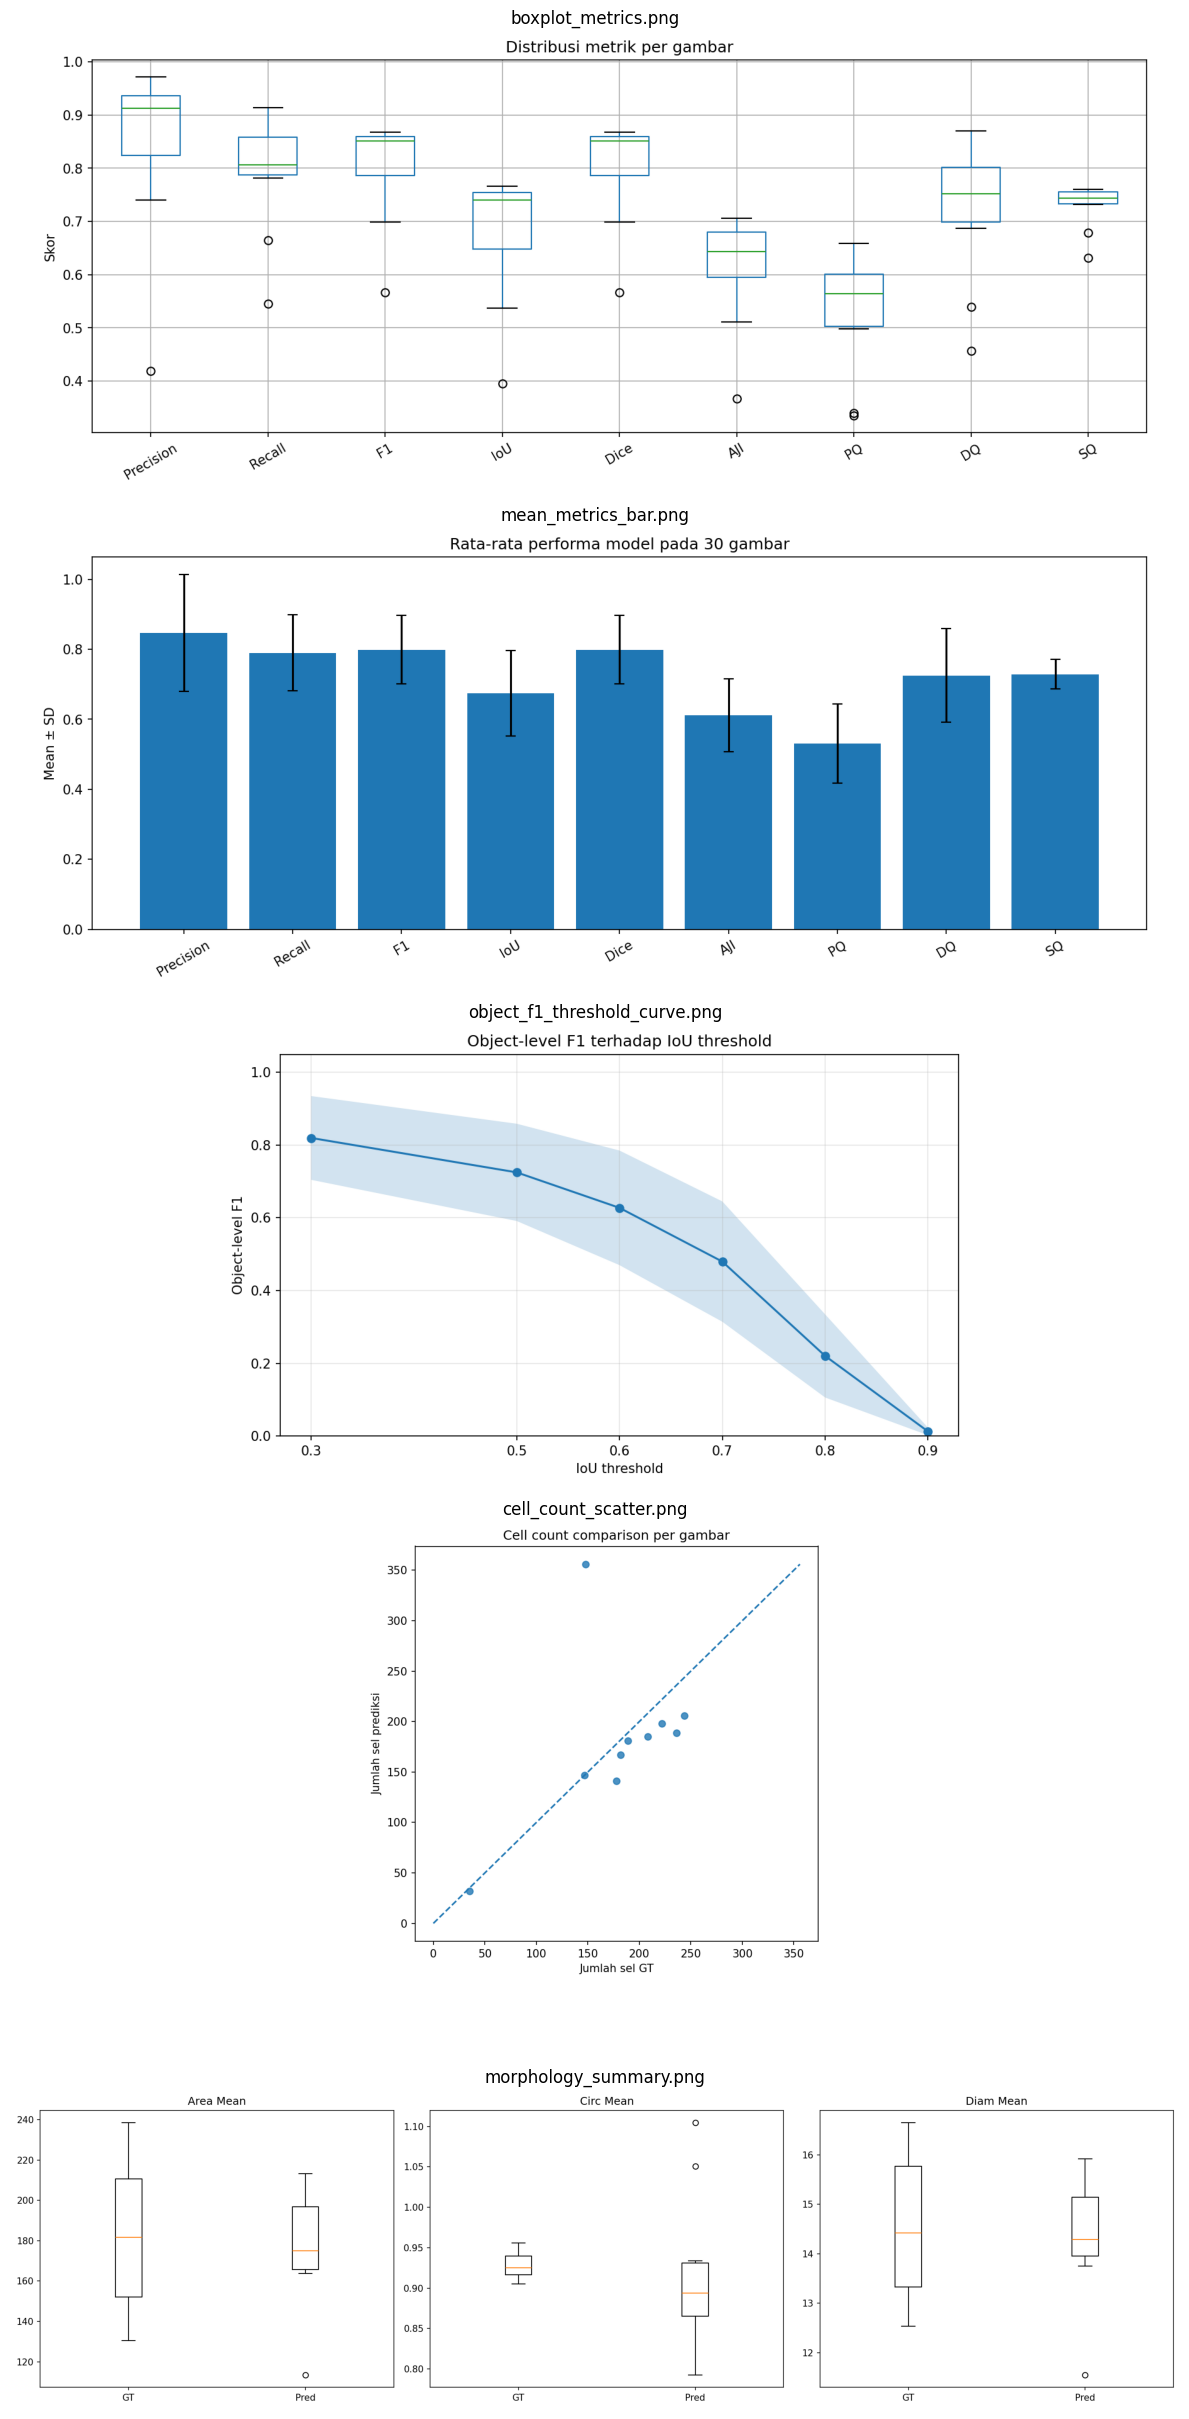

In [13]:

# =========================
# PLOT RINGKASAN DATASET
# =========================
plot_metric_boxplots(metrics_df, SUMMARY_DIR / "boxplot_metrics.png")
plot_metric_means(metrics_df, SUMMARY_DIR / "mean_metrics_bar.png")
plot_object_f1_curve(metrics_df, SUMMARY_DIR / "object_f1_threshold_curve.png")
plot_cell_count_scatter(metrics_df, SUMMARY_DIR / "cell_count_scatter.png")
plot_morphology_summary(metrics_df, SUMMARY_DIR / "morphology_summary.png")

summary_preview_paths = [
    SUMMARY_DIR / "boxplot_metrics.png",
    SUMMARY_DIR / "mean_metrics_bar.png",
    SUMMARY_DIR / "object_f1_threshold_curve.png",
    SUMMARY_DIR / "cell_count_scatter.png",
    SUMMARY_DIR / "morphology_summary.png",
]

existing = [p for p in summary_preview_paths if p.exists()]
print("Plot ringkasan yang tersimpan:")
for p in existing:
    print(" -", p)

if existing:
    fig, axes = plt.subplots(len(existing), 1, figsize=(12, 5 * max(len(existing), 1)))
    if len(existing) == 1:
        axes = [axes]

    for ax, img_path in zip(axes, existing):
        ax.imshow(io.imread(str(img_path)))
        ax.set_title(img_path.name)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


## Struktur output

Notebook ini akan menghasilkan struktur folder seperti berikut:

```text
StarDist_Fast_GridSearch_V3/
├── paired_input_files.csv
├── run_config.json
├── model_resolution_info.json
├── 01_grid_search/
│   ├── stage1_light_results.csv
│   ├── stage2_fine_light_results.csv   (jika mode coarse_to_fine)
│   ├── all_light_grid_results.csv
│   ├── topk_full_evaluation.csv
│   ├── best_params.json
│   ├── best_metrics.json
│   ├── grid_search_results.xlsx
│   └── best_tuning_visual/
├── 02_hasil_inferensi_per_gambar/
│   └── <nama_gambar>/
│       ├── *_pred_instance.tif
│       ├── *_pred_binary.png
│       ├── *_metrics.csv
│       ├── *_metrics.json
│       ├── *_panel.png
│       ├── *_overlay.png
│       └── *_error_map.png
└── 03_ringkasan_rata_rata_metrik/
    ├── per_image_metrics.csv
    ├── per_image_metrics.xlsx
    ├── aggregate_mean_std.csv
    ├── aggregate_mean_std.xlsx
    ├── failed_cases.csv
    ├── boxplot_metrics.png
    ├── mean_metrics_bar.png
    ├── object_f1_threshold_curve.png
    ├── cell_count_scatter.png
    └── morphology_summary.png
```
